In [7]:
# Import necessary libraries
import pandas as pd
from collections import defaultdict
import geopandas as gpd
from shapely import wkt
import shapely

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
%matplotlib inline
import datetime
import time
import numpy as np
import xml.etree.ElementTree as ET 
import matsim

import utm
from shapely.geometry import Polygon, Point
import gzip
from matplotlib import cm

import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import matplotlib as mpl
from matplotlib.lines import Line2D
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap
import json



In [8]:
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}


# Wende die Funktion auf die Spalte raumtyp an und erstelle die neue Spalte area_type
regionclusters['area_type_agg'] = regionclusters['raumtyp'].apply(determine_area_type)
regionclusters['area_type'] = regionclusters['raumtyp'].astype(str).map(category_dict)

# Explode the multipolygons into individual polygons
regionclusters_split = regionclusters.explode(index_parts=False)

# Reset index to clean up the DataFrame
regionclusters_split.reset_index(drop=True, inplace=True)

# Ensure regionclusters_split has a unique 'id' column for each geometry
if 'id' not in regionclusters_split.columns:
    regionclusters_split = regionclusters_split.reset_index().rename(columns={'index': 'id'})

# Display the resulting DataFrame
regionclusters_split

C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


,id,name,raumtyp,area_type_agg,area_type,geometry
0,0,Metropoles Zentrum,1,Urban,Metropolitan Center,"POLYGON ((550245.757 5803780.217, 550498.506 5..."
1,1,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((551841.918 5799807.714, 551822.177 5..."
2,2,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((548246.648 5803396.842, 548436.729 5..."
3,3,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((551382.558 5803547.894, 551322.051 5..."
4,4,Zentrumsnah verdichtete Mischnutzung,3,Urban,Dense Mixed Use,"POLYGON ((550296.319 5800661.942, 550326.482 5..."
...,...,...,...,...,...,...
92,92,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((555171.141 5811301.777, 555348.531 5..."
93,93,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((553603.43 5818427.593, 553504.77 581..."
94,94,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((569144.127 5792666.928, 569149.889 5..."
95,95,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((567727.813 5795421.313, 567684.597 5..."


In [9]:
# --- Demand-Shape einlesen (Dienstag) ---
demand_path = "input/hagrid_parcel_demand_2025-05-13_(Tuesday).shp"
parcel_input_demand_tuesday = gpd.read_file(demand_path)
# CRS prüfen
assert parcel_input_demand_tuesday.crs.to_epsg() == 25832, "Demand CRS ist nicht EPSG:25832"

demand_agg = parcel_input_demand_tuesday.groupby("name")[["dhl_b2b", "dhl_b2c"]].sum()
demand_agg["total_dhl"] = demand_agg["dhl_b2b"] + demand_agg["dhl_b2c"]

In [10]:
# --- Calculate parcel delivery density per area type (parcels/km², 8 area types) ---
import geopandas as gpd

# 1. Assign area type to each point via spatial join
parcel_input_demand_tuesday = gpd.sjoin(
    parcel_input_demand_tuesday,
    regionclusters[['geometry', 'raumtyp']],
    how='left', predicate='within')

# 2. Optionally assign area type name
category_dict_int = {int(k): v for k, v in category_dict.items()}
parcel_input_demand_tuesday['main_area_type_name'] = parcel_input_demand_tuesday['raumtyp'].map(category_dict_int)

# 3. Calculate total parcels per point (sum of all B2B/B2C columns)
carrier_cols = ['ama_b2b','ama_b2c','dhl_b2b','dhl_b2c','dpd_b2b','dpd_b2c','fxt_b2b','fxt_b2c','gls_b2b','gls_b2c','her_b2b','her_b2c','ups_b2b','ups_b2c']
parcel_input_demand_tuesday['total_parcels'] = parcel_input_demand_tuesday[carrier_cols].sum(axis=1)

# 4. Area per area type (in km²)
if regionclusters.crs.to_epsg() != 25832:
    regionclusters = regionclusters.to_crs(25832)
    
regionclusters['area_km2'] = regionclusters.geometry.area / 1e6  # m² -> km²
area_by_type = regionclusters.groupby('raumtyp')['area_km2'].sum()

# area_by_type = regionclusters.groupby('raumtyp').geometry.area / 1e6  # m² -> km²

# 5. Total parcels per area type
parcels_by_type = parcel_input_demand_tuesday.groupby('raumtyp')['total_parcels'].sum()

# 6. Parcel delivery density per area type (parcels/km²)
density = (parcels_by_type / area_by_type).rename('parcels_per_km2')

# 7. Output as DataFrame, sorted by area type 1-8
density_df = density.reset_index()
density_df['area_type'] = density_df['raumtyp'].map(category_dict_int)
density_df = density_df.sort_values('raumtyp')
density_df = density_df[['raumtyp','area_type','parcels_per_km2']]
density_df['parcels_per_km2'] = density_df['parcels_per_km2'].round(1)
density_df

,raumtyp,area_type,parcels_per_km2
0,1.0,Metropolitan Center,2799.2
1,2.0,High-Density Residential Use,1783.4
2,3.0,Dense Mixed Use,638.0
3,4.0,Residential Use,270.9
4,5.0,Industrial Use,169.5
5,6.0,Urbanized Periphery,118.4
6,7.0,Rural with Industrial Influence,32.2
7,8.0,Rural without Industrial Influence,26.3


In [11]:
# --- Parcel delivery density per regionclusters_split geometry (fine-grained, not aggregated by raumtyp) ---
import geopandas as gpd

# Ensure CRS is correct
if regionclusters_split.crs.to_epsg() != 25832:
    regionclusters_split = regionclusters_split.to_crs(25832)

# 1. Spatial join: assign regionclusters_split geometry to each parcel point
parcel_input_demand_tuesday = gpd.sjoin(
    parcel_input_demand_tuesday,
    regionclusters_split[['geometry', 'id', 'raumtyp']],
    how='left', predicate='within', rsuffix='_split')

# 2. Calculate total parcels per point (already present as 'total_parcels')

# 3. Area per regionclusters_split geometry (in km²)
regionclusters_split['area_km2'] = regionclusters_split.geometry.area / 1e6

# 4. Total parcels per regionclusters_split geometry
parcels_by_geom = parcel_input_demand_tuesday.groupby('id')['total_parcels'].sum()

# 5. Parcel delivery density per regionclusters_split geometry (parcels/km²)
density_split = (parcels_by_geom / regionclusters_split.set_index('id')['area_km2']).rename('parcels_per_km2')

# 6. Output as DataFrame, sorted by id
density_split_df = density_split.reset_index()
density_split_df = density_split_df.merge(regionclusters_split[['id', 'raumtyp']], on='id', how='left')
density_split_df['parcels_per_km2'] = density_split_df['parcels_per_km2'].round(1)
density_split_df = density_split_df[['id', 'raumtyp', 'parcels_per_km2']]


print("Density Median: ", density_split_df["parcels_per_km2"].median())


Density Median:  63.7


In [12]:
# Read the CSV file
folder = "input/"
areas = pd.read_csv( folder + "plz_areas.csv")  

# Convert the 'WKT' column to Shapely MultiPolygon geometry
areas['geometry'] = areas['WKT'].apply(lambda wkt_str: wkt.loads(wkt_str))

# Create a GeoDataFrame
gdf_areas = gpd.GeoDataFrame(areas, geometry='geometry')

# Set the coordinate reference system (CRS)
gdf_areas.crs = 'EPSG:25832'  # Set the appropriate CRS if it's different


# Import Network
# MATSim network als Geopandas dataframe inkl. LINESTRINGS einlesen
# network = matsim.read_network('D:\\Hannover Daten\\MatSim\\Network XT\\car_network_encfix.xml.gz').as_geo().set_crs('epsg:25832') # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
network = matsim.read_network('input/car_network_encfix.xml.gz').as_geo().set_crs('epsg:25832')
# dict mit Netzwerk Link Längen
# link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
network.head()

# falls vorhanden Ergebnisse der nächsten Zellen laden, sonst überspringen
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)
with open('input/networkplus.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    networkplus = pd.read_pickle(pickle_file)     




link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
link_geometry = network[['link_id', 'geometry']].set_index('link_id').to_dict()['geometry']
# dict mit Netzwerk Link Raumtypen
link_raumtyp = networkplus['raumtyp'].to_dict()

C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


In [13]:
# Create a dictionary linking each area type code to its description
area_type_dict = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

from matplotlib.colors import to_hex
# Define the desired order of legend labels in English
# Create a dictionary linking each category to a color



category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}



category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b"
}



# Create a dictionary linking each category to a color
category_color = {category: i / (len(category_color_dict) - 1) for i, category in enumerate(category_color_dict)}

# Create the colormap
cmap = LinearSegmentedColormap.from_list("custom_cmap", sns.color_palette("viridis_r", len(category_color_dict))[::-1])

# Convert the colormap to a dictionary
palette_dict = {cat: to_hex(cmap(category_color[cat])) for cat in category_color_dict}


In [18]:
# def Methoden

# vehicle string pattern
def parse_events(event_file):
    """
    This function parses events from a given event file. It filters out events of type 'left link' and 'actstart'.
    It also counts the number of events for different types of vehicles and stores the last link for each vehicle.
    
    Args:
        event_file (str): The path to the event file to be parsed.
        
    Returns:
        vehicle_tour (dict): A dictionary mapping each vehicle to a list of links in its tour.
        service_events (dict): A dictionary mapping each person to a list of service events.
        network_volumes (DataFrame): A DataFrame containing the counts of each type of vehicle on each link.
    """
    
    # Only returns events of type 'left link' and 'actstart:
    events = matsim.event_reader(event_file, types='left link,actstart')

    # defaultdict creates a blank dict entry on first reference; similar to {} but more friendly
    link_counts_trucks = defaultdict(int)
    link_counts_vans = defaultdict(int)
    link_counts_bikes = defaultdict(int)
    link_counts_cars = defaultdict(int)

    vehicle_tour = defaultdict(list)
    service_events = defaultdict(list)
    last_link = defaultdict(str)
    
    vehicle_services = defaultdict(list)

    for event in events:
        # skip next day events
        if event['time'] > DAYEND: continue

        # on link left
        if event['type'] == 'left link':
            vehicle = event['vehicle']
            # fix broken ID encodings in basecase
            # vehicle = vehicle.encode('Windows 1252').decode('UTF-8') # für die Auswertung egal
            # identify CEP truck
            if '_Supply_Vehicle_' in vehicle or '_veh_supply_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_trucks[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
            # identify vans (CEP & eGrocery)
            elif '_CEP_Vehicle_' in vehicle or '_veh_cep_' in vehicle or '_egrocery_van_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_vans[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
            # identify bikes
            elif '_cargoBike_' in vehicle or '_cargobike_' in vehicle:
                if event['link'] != last_link[vehicle]:
                    link_counts_bikes[event['link']] += 1
                    vehicle_tour[vehicle].append(event['link'])
                    last_link[vehicle] = event['link']
        elif event['type'] == 'actstart':
            person = event['person']
            # fix broken ID encodings in basecase
            # person = person.encode('Windows 1252').decode('UTF-8') # für die Auswertung egal
            # catch last tour link
            if event['actType'] == 'end':
            # identify CEP truck persons
                if '_Supply_Vehicle_' in person or '_veh_supply_' in person:
                    link_counts_trucks[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
                # identify van persons
                elif '_CEP_Vehicle_' in person or '_veh_cep_' in person or '_egrocery_van_' in person:
                    link_counts_vans[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
                # identify bike persons
                elif '_cargoBike_' in person or '_cargobike_' in vehicle:
                    link_counts_bikes[event['link']] += 1
                    vehicle_tour[person].append(event['link'])
            # catch services
            elif event['actType'] == 'service':
                service_events[person].append(event['link'])
                vehicle_services[person].append(event)
    


    # convert link_counts dict to a pandas dataframe
    link_counts_trucks = pd.DataFrame.from_dict(link_counts_trucks, orient='index', columns=['truck_count']).rename_axis('link_id')
    link_counts_vans = pd.DataFrame.from_dict(link_counts_vans, orient='index', columns=['van_count']).rename_axis('link_id')
    link_counts_bikes = pd.DataFrame.from_dict(link_counts_bikes, orient='index', columns=['bike_count']).rename_axis('link_id')
    link_counts_cars = pd.DataFrame.from_dict(link_counts_cars, orient='index', columns=['car_count']).rename_axis('link_id')

    # attach counts to our Geopandas network from above
    network_volumes = network.merge(link_counts_trucks, on='link_id', how='left').merge(link_counts_vans, on='link_id', how='left').merge(link_counts_bikes, on='link_id', how='left').merge(link_counts_cars, on='link_id', how='left')
    network_volumes['car_count'] = network_volumes['car_count'].fillna(0)
    network_volumes['truck_count'] = network_volumes['truck_count'].fillna(0)
    network_volumes['van_count'] = network_volumes['van_count'].fillna(0)
    network_volumes['bike_count'] = network_volumes['bike_count'].fillna(0)
    network_volumes['total_count'] = network_volumes['truck_count'] + network_volumes['van_count'] + network_volumes['bike_count']

    return vehicle_tour, service_events, network_volumes, vehicle_services


def vehicle_stats(vehicle_tour, service_events):
    """
    This function calculates statistics for each vehicle, including the number of services, total tour length,
    distance to the first service, and distribution of services over different types of areas.
    
    Args:
        vehicle_tour (dict): A dictionary mapping each vehicle to a list of links in its tour.
        service_events (dict): A dictionary mapping each person to a list of service events.
        
    Returns:
        veh_df (DataFrame): A DataFrame containing statistics for each vehicle.
    """
        
    # init Ergebnis Objekte
    vehicle_stats = list()

    # Loop über Fahrzeuge und ihre Services
    for veh, ser in service_events.items():
        # Unterscheidung Fahrzeugtypen
        if '_Supply_Vehicle_' in veh or '_veh_supply_' in veh:
            c = 'truck'            
        if '_CEP_Vehicle_' in veh or '_veh_cep_' in veh or '_egrocery_van_' in veh:
            c = 'van'
        if '_cargoBike_' in veh or '_cargobike_' in veh:
            c = 'bike'
        
        # tourlen = 0
        # firstservicedist = None
        # # Loop über alle Tourlinks des Fahrzeuges
        # for link in vehicle_tour[veh]:
        #     # falls erster Service erreicht, Strecke bis dahin speichern
        #     if link == ser[0] and firstservicedist is None:
        #         firstservicedist = tourlen
        #     # Streckenlänge aufsummieren
        #     tourlen += link_length[link]
        # # Sonderfälle abfangen, wo ein Service kurz vor Tagesende beginnt und am nächsten Tag weitergefahren wird
        # if firstservicedist is None: firstservicedist = tourlen

        tourlen = 0
        firstservicedist = None
        service_dists = dict()

        visited_links = vehicle_tour[veh]
        if not ser:
            continue

        for link in visited_links:
            # Strecke aufsummieren
            link_km = link_length[link] / 1000  # Direkt km
            tourlen += link_km
            for s in ser:
                # Sobald Servicepunkt erreicht (einmalig erfassen)
                if link == s and s not in service_dists:
                    service_dists[s] = tourlen
                    if firstservicedist is None:
                        firstservicedist = tourlen  # Speichere ersten Treffer

        # Fallback: falls ein Service nicht in der Tour auftaucht
        for s in ser:
            if s not in service_dists:
                service_dists[s] = tourlen
        if firstservicedist is None:
            firstservicedist = tourlen
           
        indexService = 0
        start_service_distance_count = False
        currentServiceDist = 0
        serviceDistList= []    

        # Service Verteilung über Raumtypen ermitteln
        raumtypen_services = defaultdict(int)
        for s in ser:
            rt = link_raumtyp.get(s, 0) # keinem Raumtyp zugeordnet -> 0
            raumtypen_services[rt] += 1        
    

        summ_service_distances = 0
        previous_time = 0     


        vehicle_stats.append([
            veh, c, len(ser),
            tourlen ,
            firstservicedist ,
            raumtypen_services,
            service_dists,
            firstservicedist   # explizite Spalte für initial_delivery_distance
        ])


    # Dataframe aus Liste
    veh_df = pd.DataFrame(vehicle_stats, columns=[
        'vehicle_id', 'veh_class', 'service_num',
        'tour_km', 'first_service_dist',
        'raumsplit', 'service_dists',
        'initial_delivery_distance'
    ])

    return veh_df

# Definition of help-methods needed for the convertion process

# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

    
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
        
# Definition of needen Classes: Carrier, Vehicle, Plan & Service with Variables

# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data Container storing all availble Infomation from the CSV-File
class Service(): 
    """
    This class represents a Service which is a data Container storing all available Information from the CSV-File.
    """
        
    def __init__(self, serviceType , serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID 
        self.capacityDemand = capacityDemand 
        self.duration = duration 
        self.link = link 
        self.extra_attributes = extra_attributes or {}
        
    def __str__(self):
        return "[Service ID: " + str(self.serviceID) + "(Type: " + str(self.serviceType) + ") with a CapacityDemand of " + str(self.capacityDemand) +" to Link: " + str(self.link) + "]"
    
    def __repr__(self):
        return self.__str__()

    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)
    
    def getServiceType(self): 
        return self.serviceType
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getDemand(self): 
        return self.capacityDemand
        
    def getServiceID(self): 
        return self.serviceID
    
    def getServiceLink(self): 
        return self.serviceID
    
def extract_provider(vehicle_id):
    """
    This function extracts the provider from the vehicle ID.
    
    Args:
        vehicle_id (str): The ID of the vehicle.
        
    Returns:
        str: The name of the provider.
    """
        
    return vehicle_id.split("_")[1]

def extract_veh_size(vehicle_id):
    """
    Extracts the vehicle size from the vehicle ID by looking for 'size_' and returning the next token.
    
    Args:
        vehicle_id (str): The ID of the vehicle.
        
    Returns:
        str: The vehicle size (e.g., 'l', 'm', 'l'), or 'unknown' if not found.
    """
    try:
        parts = vehicle_id.split("size_")
        if len(parts) > 1:
            return parts[1].split("_")[0]
        else:
            return "unknown"
    except Exception as e:
        print(f"Error extracting vehicle size from '{vehicle_id}': {e}")
        return "unknown"

def extract_main_area_type(raumsplit):
    """
    This function extracts the main area type from the raumsplit.
    
    Args:
        raumsplit (dict): The dictionary containing the raumsplit.
        
    Returns:
        str: The main area type.
    """
        
    return max(raumsplit.items(), key=lambda x: x[1])[0]

def process_vehicle_data(veh_df_van):
    """
    This function processes the vehicle data and adds provider, vehicle size, and main area type to the DataFrame.
    
    Args:
        veh_df_van (DataFrame): The DataFrame containing the vehicle data.
        
    Returns:
        DataFrame: The processed DataFrame.
    """
        
    veh_df_van['provider'] = veh_df_van['vehicle_id'].apply(extract_provider)
    veh_df_van['veh_size'] = veh_df_van['vehicle_id'].apply(extract_veh_size)
    veh_df_van['main_area_type'] = veh_df_van['raumsplit'].apply(extract_main_area_type)

    return veh_df_van

def get_vehicles(vehicle_tour):
    """
    This function gets the vehicles from the vehicle tour.
    
    Args:
        vehicle_tour (dict): The dictionary containing the vehicle tour.
        
    Returns:
        list: The list of vehicles.
    """
        
    return [vehicle for vehicle in vehicle_tour if "_supply_" not in vehicle]

def create_plot_data(vehicles, event_file):
    """
    This function creates the plot data.
    
    Args:
        vehicles (list): The list of vehicles.
        event_file (str): The path to the event file.
        
    Returns:
        DataFrame: The DataFrame containing the plot data.
    """
        
    plot_data = pd.DataFrame({
    "Start time" : [0],
    "End time" : [0],
    "Tour Duration" : [0],
    "Service Duration" : [0],
    "Travel Duration" : [0],
    }, index=[vehicles,])

    #calculate start and end time
    events = matsim.event_reader(event_file, types='actstart,actend')
    event_lists = { 'start': [], 'end': [] }

    for event in events:
        if "_supply_" in event["person"]:
            continue
        if event['actType'] == "start" and event['type'] == "actend":
            event_lists['start'].append(event)
        if event['actType'] == "end" and event['type'] == "actstart":
            event_lists['end'].append(event)
    df_start = pd.DataFrame(event_lists['start'])
    df_end = pd.DataFrame(event_lists['end'])

    for event in range(len(df_start)):
            plot_data["Start time"][df_start.iloc[event]["person"]] = df_start.iloc[event]['time']
    for event in range(len(df_end)):
            plot_data["End time"][df_end.iloc[event]["person"]] = df_end.iloc[event]['time']


    #calculate travel time - need to remove the service time
    events = matsim.event_reader(event_file, types='actstart,actend')
    event_lists = { 'start': [], 'end': [] }

    for event in events:
        if "_supply_" in event["person"]:
            continue
        if event['actType'] == "service" and event['type'] == "actend":
            event_lists['start'].append(event)
        if event['actType'] == "service" and event['type'] == "actstart":
            event_lists['end'].append(event)
    df_start = pd.DataFrame(event_lists['start'])
    df_end = pd.DataFrame(event_lists['end'])

    for row in range(len(plot_data)):
        plot_data.iloc[row]["Tour Duration"] = plot_data.iloc[row]["End time"] - (plot_data.iloc[row]["Start time"])

    startG = df_start.groupby("person")
    endG = df_end.groupby("person")

    for n,g in startG:
        time = 0

        g = g.reset_index(drop=True)   

        g2 = endG.get_group(n)
        g2 = g2.reset_index(drop=True)

        result = pd.merge(g, g2, left_index=True, right_index=True)

        for i in range(len(result)):
            time = time + (result.loc[i]["time_y"] - result.loc[i]["time_x"])

            plot_data.loc[n, "Service Duration"] = abs(time)

    for row in range(len(plot_data)):
        plot_data.iloc[row]["Travel Duration"] = plot_data.iloc[row]["Tour Duration"] - (plot_data.iloc[row]["Service Duration"])

    plot_data = plot_data.astype(str)
    # for row in range(len(plot_data)):
    #     plot_data.iloc[row]["Start time"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Start time"])))
    #     plot_data.iloc[row]["End time"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["End time"])))
    #     plot_data.iloc[row]["Tour Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Tour Duration"])))
    #     plot_data.iloc[row]["Service Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Service Duration"])))
    #     plot_data.iloc[row]["Travel Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Travel Duration"])))



    plot_data.reset_index(inplace=True)
    plot_data = plot_data.rename(columns={'level_0': 'vehicle_id'})

    plot_data["Start time formatted"] = pd.to_datetime(plot_data['Start time'], unit='s')
    plot_data["End time formatted"] = pd.to_datetime(plot_data['End time'], unit='s')
    plot_data["Tour Duration formatted"] = pd.to_datetime(plot_data['Tour Duration'], unit='s')
    plot_data["Service Duration formatted"] = pd.to_datetime(plot_data['Service Duration'], unit='s')
    plot_data["Travel Duration formatted"] = pd.to_datetime(plot_data['Travel Duration'], unit='s')

    plot_data["Start time"] = pd.to_numeric(plot_data["Start time"])
    plot_data["End time"] = pd.to_numeric(plot_data["End time"])
    plot_data["Tour Duration"] = pd.to_numeric(plot_data["Tour Duration"])
    plot_data["Service Duration"] = pd.to_numeric(plot_data["Service Duration"])
    plot_data["Travel Duration"] = pd.to_numeric(plot_data["Travel Duration"])
    
    return plot_data

def parse_carriers_from_xml(root):
    """
    This function parses carriers from an XML root.
    
    Args:
        root (ElementTree): The XML root to parse carriers from.
        
    Returns:
        list: The list of carriers.
    """

    carriers = []
    totalVeh = 0
    ns = {"m": "http://www.matsim.org/files/dtd"}

    for carrierXML in root.findall("m:carrier", ns):
        carrierID = carrierXML.attrib.get("id")
        if "supply" in carrierID:
            continue

        newCarrier = Carrier(carrierID)

        for attributeXML in carrierXML.findall("m:attributes", ns):
            for attribute in attributeXML.findall("m:attribute", ns):
                if attribute.attrib.get("name") == "missedParcelDeliveriesAsString":
                    missedParcels = attribute.text
                    missedParcels = missedParcels.replace("[", "").replace("]", "").replace(" ", "")
                    missedServicePerCarrier = missedParcels.split(",")
                    newCarrier.setMissedDeliveries(missedServicePerCarrier)

        for serviceXML in carrierXML.findall(".//m:service", ns):
            serviceID = serviceXML.attrib.get("id")

            serviceCapacityDemand = int(serviceXML.attrib.get("capacityDemand"))
            serviceDuration = serviceXML.attrib.get("serviceDuration")
            serviceLink = serviceXML.attrib.get("to")

            known_keys = {"id", "capacityDemand", "serviceDuration", "to"}
            extra_attrs = {k: v for k, v in serviceXML.attrib.items() if k not in known_keys}

            attributes_element = serviceXML.find("m:attributes", ns)
            if attributes_element is not None:
                for attr in attributes_element.findall("m:attribute", ns):
                    key = attr.attrib.get("name")
                    value = attr.text
                    if key in ["b2b", "b2c"]:
                        try:
                            value = int(value)
                        except ValueError:
                            value = 0
                    extra_attrs[key] = value

            newService = Service(
                "service",
                serviceID,
                serviceCapacityDemand,
                serviceDuration,
                serviceLink,
                extra_attributes=extra_attrs
            )
            newCarrier.addService(newService)

        for plan in carrierXML.findall(".//m:plan", ns):
            if plan.attrib.get("selected") == "true":
                i = 0
                for tour in plan.findall(".//m:tour", ns):
                    i += 1
                    vehID = tour.attrib.get("vehicleId") + "_" + str(i)
                    vehicle = Vehicle(vehID, "cep")                    

                    b = 0
                    c = 0

                    activities = {}
                    legs = {}
                    routes = {}

                    for act in tour.findall(".//m:act", ns):
                        actType = act.attrib.get("type")
                        if actType == "start":
                            activities[actType] = act
                        elif actType == "end":
                            activities[actType] = act
                        else:
                            actID = act.attrib.get("serviceId")
                            activities[actID] = act

                    for leg in tour.findall(".//m:leg", ns):
                        legs["leg_" + str(b)] = leg
                        b += 1

                    for route in tour.findall(".//m:route", ns):
                        if route.text is None:
                            routes["route_" + str(c)] = None
                        else:
                            routes["route_" + str(c)] = route.text.split(" ")
                        c += 1

                    for key, value in legs.items():
                        routeKey = "route_" + str(key.split("_")[1])
                        route = routes.get(routeKey)
                        value.attrib["route"] = route

                    vehiclePlan = Plan("plan_" + vehID, vehicle, activities, legs)
                    vehiclePlan.createInternalPlanSequence()
                    vehicle.addVehiclePlan(vehiclePlan)
                    newCarrier.addVehicle(vehicle)

                totalVeh += newCarrier.getNumberOfVehicles()

        carriers.append(newCarrier)

    return carriers



def calculate_costs(row):
    veh_time_cost = 22.87 / 3600  # Kosten pro Sekunde

    if "size_l" in row['vehicle_id']:
        veh_cap, veh_fix, veh_km_cost = 230, 189.15, 0.386
    elif "size_m" in row['vehicle_id']: 
        veh_cap, veh_fix, veh_km_cost = 165, 171.78, 0.372
    else:
        if "supply_light_van" in row['vehicle_id']:
            veh_cap, veh_fix, veh_km_cost = 230, 189.15, 0.386
        elif "light" in row['vehicle_id']:
            veh_cap, veh_fix, veh_km_cost = 1000, 550.63, 0.48643
        else:
            veh_cap, veh_fix, veh_km_cost = 2000, 618.55, 0.555126     
      
     
    vehicle_fix_cost = veh_fix
    vehicle_km_cost = row["tour_km"] * veh_km_cost
    vehicle_time_cost = row["Tour Duration"] * veh_time_cost

    overtime_seconds = max(0, row["Tour Duration"] - (7.5 * 3600))
    overtime_cost = overtime_seconds * veh_time_cost

    vehicle_cost = vehicle_fix_cost + vehicle_km_cost + overtime_cost

    return pd.Series([vehicle_fix_cost, vehicle_km_cost, vehicle_time_cost, overtime_cost, vehicle_cost])



def add_vehicle_demand_to_result(carriers, result):
    
    """
    This function adds vehicle demand to the result DataFrame.
    
    Args:
        carriers (list):The list of carriers.
        result (DataFrame): The DataFrame to add vehicle demand to.
        
    Returns:
        DataFrame: The DataFrame with added vehicle demand.
    """

    required_cols = [
        'deliveries', 'missed deliveries', 'b2b_ration', 'b2c_ration',
        'ration_check', 'vehicle_load_factor', 'vehicle_deliver_factor',
        'vehicle_fix_cost', 'vehicle_km_cost', 'vehicle_time_cost',
        'overtime_cost', 'vehicle_cost', 'service_num'
    ]
    for col in required_cols:
        if col not in result.columns:
            result[col] = np.nan
    expected_ids = []
    
        
    veh = 0
    fail = 0

    # 1. Create a new dictionary to hold vehicle-service mappings
    vehicle_services_dict = {}

    for c in carriers:
        missedDeliveries = c.getMissedDeliveries()
        missed_deliveries_set = set(missedDeliveries) 

        services = c.getServices()

        print(f"🔍 Carrier {c.getCarrierId()} has {len(c.getVehicles())} vehicles")
        
        
        for k, v in c.getVehicles().items():
            veh = veh + 1 
            result_df_id = "freight_" + c.getCarrierId()+"_veh_"+v.getVehicleId()     
            expected_ids.append(result_df_id)   
         
            veh_df_res = result[result.vehicle_id == result_df_id]    
            if (len(veh_df_res) != 1):
                print(result_df_id)
                fail = fail + 1    
                
            mask = result.vehicle_id == result_df_id
            if mask.sum() == 0:
                print(f"⚠️ ID not found in result: {result_df_id}")   
            
            totalVehDemand = 0            
            missedParcels = 0

            b2b = 0
            b2c = 0

            # 2. Extract services for this vehicle
            veh_services = []
            services_dict = {s.getServiceID(): s for s in services}

            for a in v.getPlans()[0].activities:
                if "service" in a:
                    for s in services:
                        if a == s.getServiceID():
                            service = services_dict.get(a)
                            veh_services.append(service)

                            service_id = s.getServiceID()
                            service_b2b = int(s.getAttribute("b2b", 0))
                            service_b2c = int(s.getAttribute("b2c", 0))

                            if service_b2b == 0 and service_b2c == 0:                                
                                if "B2B" in service_id:
                                    service_b2b = s.getDemand()
                                elif "B2C" in service_id:
                                    service_b2c = s.getDemand()
                                else:
                                    raise ValueError(f"Service ID does not indicate B2B or B2C: {service_id}")

                            # Nachfrage aufsummieren
                            b2b += service_b2b
                            b2c += service_b2c
                            serviceDemand = service_b2b + service_b2c
                            totalVehDemand += serviceDemand

                            merged = s.getAttribute("mergedMetadata", None)
                            
                            if service_id in missed_deliveries_set:
                                missedParcels += serviceDemand  
                            elif merged:
                                try:
                                    merged_dict = json.loads(merged)

                                    # Validierung: mixed muss zu merged passen
                                    if "MIXED" not in service_id.upper():
                                        print(f"⚠️ Warning: mergedMetadata found, but service ID does not indicate MIXED: {service_id}")

                                    for sid, md in merged_dict.items():
                                        if sid in missed_deliveries_set:
                                            # Sub-service demand: prefer capacity, else len(weights), else 1
                                            sub_cap_raw = md.get("capacity", 0)
                                            try:
                                                sub_cap = int(sub_cap_raw)
                                            except Exception:
                                                sub_cap = 0

                                            sub_weights_raw = md.get("weights", [])
                                            # Normalize weights to a list
                                            if isinstance(sub_weights_raw, str):
                                                try:
                                                    parsed = json.loads(sub_weights_raw)
                                                    sub_weights = parsed if isinstance(parsed, list) else [parsed]
                                                except Exception:
                                                    sub_weights = [sub_weights_raw]
                                            elif isinstance(sub_weights_raw, (list, tuple)):
                                                sub_weights = list(sub_weights_raw)
                                            else:
                                                # float/None/other
                                                sub_weights = []

                                            # Assert consistency if both present
                                            if sub_cap > 0 and len(sub_weights) > 0:
                                                assert sub_cap == len(sub_weights), (
                                                    f"Mismatch in merged service {sid}: "
                                                    f"capacity={sub_cap}, len(weights)={len(sub_weights)}"
                                                )

                                            # Final sub-demand
                                            sub_demand = sub_cap if sub_cap > 0 else (len(sub_weights) if len(sub_weights) > 0 else 1)

                                            # Count only missed sub-services
                                            if sid in missed_deliveries_set:
                                                missedParcels += sub_demand
                                except Exception as e:
                                    print(f"⚠️ Error while parsing mergedMetadata for {service_id}: {e}")


                                
                                    
            vehicle_services_dict[result_df_id] = veh_services                         
            veh_cap = 230 if "size_l" in result_df_id else 165

            b2b_ration = b2b / totalVehDemand
            b2c_ration = b2c / totalVehDemand
            
            result.loc[result.vehicle_id == result_df_id, 'b2b_ration'] = b2b_ration
            result.loc[result.vehicle_id == result_df_id, 'b2c_ration'] = b2c_ration
            result.loc[result.vehicle_id == result_df_id, 'ration_check'] = b2b_ration + b2c_ration

            result.loc[result.vehicle_id == result_df_id, 'deliveries'] = totalVehDemand
            if result[result.vehicle_id == result_df_id].empty:
                print(f"Assignment failed for: {result_df_id}")
            
            result.loc[result.vehicle_id == result_df_id, 'missed deliveries'] = round(missedParcels,0)
            
             # Anwenden der Funktion auf den DataFrame
            cols = ['vehicle_fix_cost', 'vehicle_km_cost', 'vehicle_time_cost', 'overtime_cost', 'vehicle_cost']
            result[cols] = result.apply(calculate_costs, axis=1)
             

            result.loc[result.vehicle_id == result_df_id, 'vehicle_load_factor'] = totalVehDemand / veh_cap
            result.loc[result.vehicle_id == result_df_id, 'vehicle_deliver_factor'] = (totalVehDemand - missedParcels) / totalVehDemand
    
    validate_vehicle_id_assignment(result, expected_ids)
    
    result['deliveries_per_stop'] = result['deliveries'] / result['service_num']
    result['Hannover'] = result['vehicle_id'].apply(lambda x: any(plz in x for plz in plzList))

    result['services'] = result['vehicle_id'].map(vehicle_services_dict)
    
    return result

def validate_vehicle_id_assignment(result, expected_ids):
    """
    Validates whether all expected vehicle IDs are present in the result DataFrame.
    Prints helpful diagnostics for debugging.
    
    Args:
        result (DataFrame): The result DataFrame after add_vehicle_demand_to_result.
        expected_ids (list): List of vehicle_id strings that should exist in result.
    """
    actual_ids = result['vehicle_id'].astype(str).tolist()

    missing_ids = [vid for vid in expected_ids if vid not in actual_ids]
    duplicate_ids = result['vehicle_id'][result['vehicle_id'].duplicated()].unique().tolist()
    empty_ids = result['vehicle_id'].isna().sum()

    print("\n📋 Vehicle ID Validation Report")
    print("──────────────────────────────")
    print(f"🔢 Expected IDs total: {len(expected_ids)}")
    print(f"✅ Found: {len(expected_ids) - len(missing_ids)}")
    print(f"❌ Missing: {len(missing_ids)}")
    print(f"🔁 Duplicates: {len(duplicate_ids)}")
    print(f"⚠️ Empty vehicle_id entries: {empty_ids}")
    
    if missing_ids:
        print("\n❌ Missing IDs (first 10 shown):")
        for mid in missing_ids[:10]:
            print(f"  - {mid}")
    
    if duplicate_ids:
        print("\n🔁 Duplicate vehicle_ids:")
        for did in duplicate_ids:
            print(f"  - {did}")



In [19]:
# This is a constant representing the number of seconds in a day.
DAYEND = 24*3600

# This is a list of postal codes (it seems) that the script will be working with.
plzList = ["30159", "30161", "30163", "30165", "30167", "30169", "30171", "30173", "30175", "30177", "30179", "30419", "30449"
           ,"30451" ,"30453" ,"30455" ,"30457" ,"30459" ,"30519" ,"30521" ,"30539" ,"30559" ,"30625" ,"30627" ,"30629",
           "30625" , "30627", "30629", "30655", "30657", "30659", "30669", "31303", "31303"]

# This is the path to the folder where input files are stored.
folderPath = "Input/SimRes/basecase_13052025_iter150_jsprit1000/"
# folderPath = "Input/SimRes/500-it/basecase_13052025/"
# folderPath = "Input/SimRes/BC_500_it_no_reduction/"

file = ""

# This is the name of the file where event data will be loaded.
eventFileName = "basecase_13052025.output_events.xml.gz"

# This is the name of the file where carrier data will be loaded.
carrierFileName = "basecase_13052025.output_carriers.xml.gz"


city = regionclusters[regionclusters.raumtyp < 7]

result_dataframes = {}
result_networks= {}

event_file = folderPath + file + eventFileName
carrier_file = folderPath + file + carrierFileName

print("Start Reading Event-file from: ", event_file)

vehicle_tour, service_events, network_volumes, vehicle_services = parse_events(event_file)    
# Clip the network_volumes GeoDataFrame to the shape of gdf_areas
clipped_network_volumes = gpd.clip(network_volumes, gdf_areas)

veh_df = vehicle_stats(vehicle_tour, service_events)
veh_df_van = veh_df[veh_df.veh_class == "van"]

veh_df_truck = veh_df[~(veh_df.veh_class == "van")]

# Call the optimized function to process the vehicle data
veh_df_van = process_vehicle_data(veh_df_van)

vehicles = get_vehicles(vehicle_tour)
plot_data = create_plot_data(vehicles, event_file)

result = plot_data.merge(veh_df_van, left_on='vehicle_id', right_on='vehicle_id')

with gzip.open(carrier_file, mode="rt") as f:
    tree = ET.parse(f)
    root = tree.getroot()

carriers = parse_carriers_from_xml(root)
result = add_vehicle_demand_to_result(carriers, result)


Start Reading Event-file from:  Input/SimRes/basecase_13052025_iter150_jsprit1000/basecase_13052025.output_events.xml.gz


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\232118948.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  network_volumes['car_count'] = network_volumes['car_count'].fillna(0)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\232118948.py:96: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  network_volumes['bike_count'] = network_volumes['bike_count'].fillna(0)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\232118948.py:467: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

🔍 Carrier fedex_30519 has 3 vehicles
🔍 Carrier dpd_30419 has 5 vehicles
🔍 Carrier dpd_30539 has 3 vehicles
🔍 Carrier dpd_30659 has 2 vehicles
🔍 Carrier dpd_30657 has 3 vehicles
🔍 Carrier dpd_30655 has 2 vehicles
🔍 Carrier gls_30449 has 2 vehicles
🔍 Carrier ups_30419 has 4 vehicles
🔍 Carrier hermes_30625 has 3 vehicles
🔍 Carrier dhl_30455_1 has 5 vehicles
🔍 Carrier hermes_30629 has 3 vehicles
🔍 Carrier hermes_30627 has 1 vehicles
🔍 Carrier dhl_30455_0 has 5 vehicles
🔍 Carrier ups_30655 has 2 vehicles
🔍 Carrier ups_30657 has 4 vehicles
🔍 Carrier ups_30659 has 3 vehicles
🔍 Carrier ups_30539 has 3 vehicles
🔍 Carrier amazon_30419_0 has 4 vehicles
🔍 Carrier gls_30559 has 4 vehicles
🔍 Carrier amazon_30419_1 has 4 vehicles
🔍 Carrier fedex_30419 has 3 vehicles
🔍 Carrier hermes_30519 has 5 vehicles
🔍 Carrier fedex_30655 has 2 vehicles
🔍 Carrier fedex_30657 has 3 vehicles
🔍 Carrier ups_30449 has 4 vehicles
🔍 Carrier fedex_30659 has 2 vehicles
🔍 Carrier fedex_30539 has 3 vehicles
🔍 Carrier dpd_305

In [20]:
import json
import re
from shapely.geometry import Point
from collections import defaultdict

vehicle_coords = defaultdict(list)
vehicle_weights = defaultdict(list)

for carrier in carriers:
    services = carrier.getServices()
    vehicles = carrier.getVehicles()

    for v in vehicles.values():
        vehicle_id = f"freight_{carrier.getCarrierId()}_veh_{v.getVehicleId()}"
        for a in v.getPlans()[0].activities:
            if "service" not in a:
                continue

            for s in services:
                if a == s.getServiceID():
                    # --- Normale Koordinate ---
                    coord_raw = s.getAttribute("coord", None)
                    if coord_raw:
                        match = re.match(r"\(([\d\.]+);([\d\.]+)\)", coord_raw)
                        if match:
                            x, y = float(match.group(1)), float(match.group(2))
                            vehicle_coords[vehicle_id].append(Point(x, y))

                    # --- Normale Gewichte ---
                    weights_raw = s.getAttribute("weights", None)
                    if weights_raw:
                        for w in re.split(r"[;,\s]+", weights_raw.strip()):
                            try:
                                weight = max(float(w), 0.1)
                                vehicle_weights[vehicle_id].append(weight)
                            except:
                                pass

                    # --- Merged Subservices ---
                    merged = s.getAttribute("mergedMetadata", None)
                    if merged:
                        try:
                            merged_dict = json.loads(merged)
                            for sub_id, meta in merged_dict.items():
                                # Koordinaten
                                if "coord" in meta and isinstance(meta["coord"], list):
                                    x, y = meta["coord"]
                                    vehicle_coords[vehicle_id].append(Point(float(x), float(y)))

                                # Gewichte
                                if "weights" in meta:
                                    for w in meta["weights"]:
                                        try:
                                            weight = max(float(w), 0.1)
                                            vehicle_weights[vehicle_id].append(weight)
                                        except:
                                            pass
                        except Exception as e:
                            print(f"⚠️ Error parsing mergedMetadata for {s.getServiceID()}: {e}")

# Koordinaten als Liste speichern (Shapely-Points oder Tupel)
vehicle_coords_df = pd.DataFrame([
    {"vehicle_id": vid, "coords_list": points}
    for vid, points in vehicle_coords.items()
])

# Gewichte als Liste speichern
vehicle_weights_df = pd.DataFrame([
    {"vehicle_id": vid, "weights_list": ws}
    for vid, ws in vehicle_weights.items()
])

# Erst Gewichte mergen
result = result.merge(vehicle_weights_df, how="left", on="vehicle_id")

# Dann Koordinaten mergen
result = result.merge(vehicle_coords_df, how="left", on="vehicle_id")

from shapely.geometry import MultiPoint
from shapely.ops import transform
import pyproj

# Funktion: Fläche in km² berechnen
project = pyproj.Transformer.from_crs("epsg:25832", "epsg:3857", always_xy=True).transform  # UTM → Meter
def calc_area_km2(coords):
    if not coords or len(coords) < 3:
        return 0.0
    try:
        poly = MultiPoint(coords).convex_hull
        poly_m = transform(project, poly)
        return round(poly_m.area / 1e6, 3)  # m² → km²
    except:
        return 0.0

# Neue Spalten berechnen
result["total_weight"] = result["weights_list"].apply(lambda ws: round(sum(ws), 2) if isinstance(ws, list) else 0.0)
result["avg_weight_per_parcel"] = result["weights_list"].apply(lambda ws: round(sum(ws)/len(ws), 2) if isinstance(ws, list) and ws else 0.0)
result["delivery_area_km2"] = result["coords_list"].apply(lambda cs: calc_area_km2(cs))


In [21]:
import json
from collections import defaultdict
import pandas as pd

# Set to True if you want to stop on the first inconsistency
STRICT_ASSERT = False

def parse_duration_seconds(val):
    """
    Accepts 'HH:MM:SS', int seconds, float seconds, or numeric-like strings.
    Returns int seconds or None.
    """
    if val is None:
        return None
    try:
        if isinstance(val, (int, float)):
            return int(round(float(val)))
        s = str(val).strip()
        if s.isdigit():
            return int(s)
        if ":" in s:
            hh, mm, ss = s.split(":")
            return int(hh) * 3600 + int(mm) * 60 + int(float(ss))
        return int(round(float(s)))
    except Exception:
        return None

def _repeat(val, n):
    """Return a list with val repeated n times, if n > 0."""
    try:
        n = int(n)
    except Exception:
        n = 0
    return [val] * max(n, 0)

# Collect per-vehicle durations and consistency diagnostics
vehicle_service_durations = defaultdict(list)
svc_level_checks = []   # one row per service for diagnostics
veh_level_expected = defaultdict(int)  # expected number of stops based on capacity sums
veh_level_actual = defaultdict(int)    # actual list length

for carrier in carriers:
    services = carrier.getServices()
    vehicles = carrier.getVehicles()
    services_by_id = {s.getServiceID(): s for s in services}

    for v in vehicles.values():
        vehicle_id = f"freight_{carrier.getCarrierId()}_veh_{v.getVehicleId()}"

        for a in v.getPlans()[0].activities:
            if "service" not in a:
                continue

            s = services_by_id.get(a)
            if s is None:
                continue

            # Expected capacity for this service
            svc_cap = None
            try:
                svc_cap = int(s.getDemand())
            except Exception:
                svc_cap = None

            used_list = []
            used_cap_sum = 0
            used_strategy = None

            merged_raw = s.getAttribute("mergedMetadata", None)
            if merged_raw:
                try:
                    merged_dict = json.loads(merged_raw)
                except Exception as e:
                    merged_dict = None
                    print(f"Warning: cannot parse mergedMetadata for {s.getServiceID()}: {e}")

                if isinstance(merged_dict, dict):
                    used_strategy = "MIXED"
                    for sub_id, meta in merged_dict.items():
                        if not isinstance(meta, dict):
                            continue
                        # sub capacity: prefer 'capacity', else len(weights), else 1
                        sub_cap = meta.get("capacity", None)
                        if sub_cap is None:
                            weights = meta.get("weights", [])
                            if isinstance(weights, str):
                                try:
                                    weights = json.loads(weights)
                                except Exception:
                                    weights = [weights]
                            if isinstance(weights, (list, tuple)):
                                sub_cap = len(weights)
                            else:
                                sub_cap = 1
                        try:
                            sub_cap = int(sub_cap)
                        except Exception:
                            sub_cap = 1
                        # sub duration
                        sub_dur = parse_duration_seconds(meta.get("serviceDuration", None))
                        if sub_dur is None:
                            # if no parseable duration, skip this sub service
                            continue
                        used_list.extend(_repeat(sub_dur, sub_cap))
                        used_cap_sum += sub_cap

            # Fallback for non MIXED or if no valid merged entries were added
            if not used_list:
                used_strategy = "SINGLE"
                dur = parse_duration_seconds(s.getAttribute("serviceDuration", None))
                if dur is None:
                    dur = parse_duration_seconds(getattr(s, "duration", None))
                # Repeat by capacityDemand if available, else single occurrence
                rep = svc_cap if isinstance(svc_cap, int) and svc_cap > 0 else 1
                used_list.extend(_repeat(dur, rep) if dur is not None else [])
                used_cap_sum = rep

            # Append to vehicle bucket
            vehicle_service_durations[vehicle_id].extend(used_list)
            veh_level_actual[vehicle_id] += len(used_list)
            if isinstance(svc_cap, int):
                veh_level_expected[vehicle_id] += svc_cap

            # Record service level check
            svc_level_checks.append({
                "vehicle_id": vehicle_id,
                "service_id": s.getServiceID(),
                "strategy": used_strategy,
                "capacityDemand_xml": svc_cap,
                "durations_count": len(used_list),
                "durations_sum_s": sum(used_list) if used_list else 0,
                "durations_example_s": used_list[:3]
            })

# Build diagnostics DataFrame
svc_checks_df = pd.DataFrame(svc_level_checks)

# Report service level inconsistencies
svc_incons = svc_checks_df[
    svc_checks_df["capacityDemand_xml"].notna() &
    (svc_checks_df["durations_count"] != svc_checks_df["capacityDemand_xml"])
]
if not svc_incons.empty:
    print("Service level inconsistency detected for the following rows (showing first 10):")
    display(svc_incons.head(10))
    if STRICT_ASSERT:
        raise AssertionError("Service level durations_count does not match capacityDemand for at least one service.")

# Build per-vehicle DataFrame and merge
vehicle_service_durations_df = pd.DataFrame(
    [{"vehicle_id": vid, "service_durations_s": durs}
     for vid, durs in vehicle_service_durations.items()]
)


# Optional vehicle level check if 'deliveries' is present in result
if "deliveries" in result.columns:
    print("Running vehicle level consistency check between 'deliveries' and durations list length...")
    
    tmp = result[["vehicle_id", "deliveries"]].copy()
    tmp["actual_len"] = tmp["vehicle_id"].map(lambda vid: len(vehicle_service_durations.get(vid, [])))
    veh_incons = tmp[tmp["deliveries"] != tmp["actual_len"]]
    if not veh_incons.empty:
        print("Vehicle level inconsistency between 'deliveries' and durations list length (showing first 10):")
        display(veh_incons.head(10))
        if STRICT_ASSERT:
            raise AssertionError("Vehicle level durations length does not match 'deliveries' for at least one vehicle.")        
        
result = result.merge(vehicle_service_durations_df, on="vehicle_id", how="left")


Running vehicle level consistency check between 'deliveries' and durations list length...


In [22]:
import pandas as pd

# Regex für carrier, PLZ und optionalen Split
pattern = r'^freight_([a-z]+)_(\d+)(?:_(\d+))?_veh'

# 1) Teile extrahieren
result[["carrier_name", "plz_gebiet", "split"]] = result["vehicle_id"].str.extract(pattern)

# 2) Split als Integer mit NA-Unterstützung
result["split"] = result["split"].astype("Int64")

# 3) Kombinierte Zielspalte carrier bauen
result["carrier"] = result.apply(
    lambda row: f"{row['carrier_name']}_{row['plz_gebiet']}"
                + (f"_{row['split']}" if pd.notna(row['split']) else ""),
    axis=1
)

# Optional prüfen
# print(result[["vehicle_id", "carrier"]].head())


In [23]:
def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'

# Umbenennen der Spalten für besser lesbare KPIs
rename_map = {
    'tour_km': 'Tour Length (km)',
    'Tour Duration': 'Tour Duration (hrs)',
    'Travel Duration': 'Driving Time (hrs)',
    'vehicle_load_factor': 'Vehicle Utilization (%)',
    'initial_delivery_distance': 'Initial Delivery Distance (km)',
    'avg_dist_wo_init': 'Mean Distance Between Stops (km)'
}
result = result.rename(columns=rename_map)

# Konvertiere Sekunden → Stunden (nur wenn noch nicht konvertiert)
for col in ['Tour Duration (hrs)', 'Driving Time (hrs)']:
    result[col] = result[col] / 3600

# Durchschnittsgeschwindigkeit berechnen (km/h)
result['Average Speed (km/h)'] = result['Tour Length (km)'] / result['Driving Time (hrs)']

result['main_area_type_agg'] = result['main_area_type'].apply(determine_area_type)
# Prozentualer Anteil der reinen Fahrzeit an der Gesamttourdauer
result['Driving Share of Tour (%)'] = (result['Driving Time (hrs)'] / result['Tour Duration (hrs)']) * 100

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
result['area_type_agg'] = result['main_area_type'].apply(determine_area_type)
result['main_area_description'] = result['main_area_type'].map(area_type_dict)


In [25]:
lowUtilization = result[result["Vehicle Utilization (%)"] < 0.05]
lowUtilization

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,service_durations_s,carrier_name,plz_gebiet,split,carrier,Average Speed (km/h),main_area_type_agg,Driving Share of Tour (%),area_type_agg,main_area_description
607,freight_dhl_30657_0_veh_cep_size_m_11_5,39342,44658,1.476667,846,1.241667,1970-01-01 10:55:42,1970-01-01 12:24:18,1970-01-01 01:28:36,1970-01-01 00:14:06,...,"[120, 120, 120, 120, 120, 240, 240]",dhl,30657,0,dhl_30657_0,22.060391,Suburban,84.085779,Suburban,Residential Use


In [31]:
result = result[result['Vehicle Utilization (%)'] >= 0.05]

In [27]:
bc = result.copy()

<Axes: title={'center': 'Vehicle Utilization Distribution'}, ylabel='Frequency'>

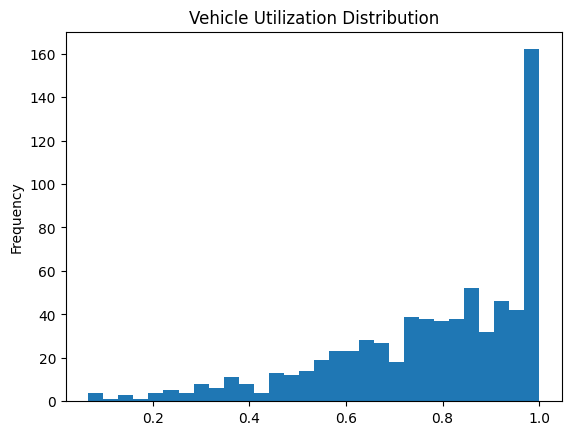

In [32]:
bc["Vehicle Utilization (%)"].plot(kind='hist', bins=30, title='Vehicle Utilization Distribution')

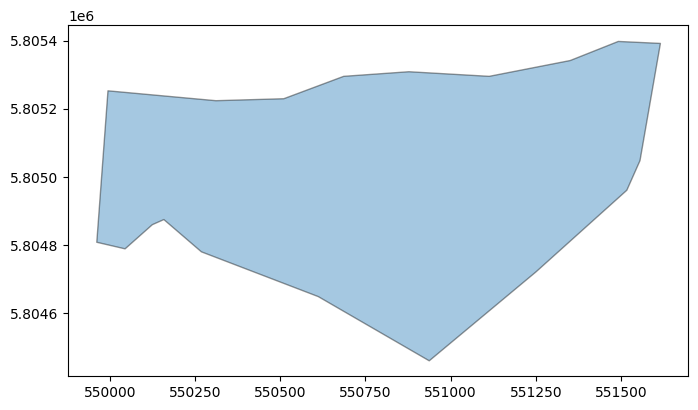

In [33]:
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# --- Read vissim_area.shp from input folder ---
import geopandas as gpd

vissim_area = gpd.read_file('input/vissim_area.shp')


# Optional: plot zur Kontrolle
ax = vissim_area.plot(edgecolor="black", alpha=0.4, figsize=(8, 8))

plt.show()


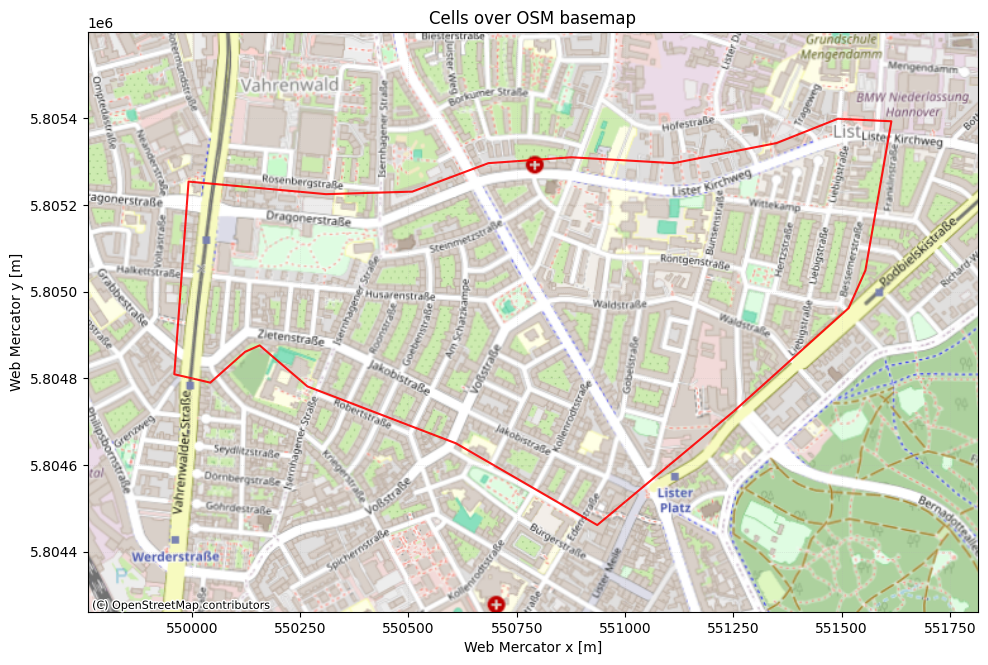

In [34]:
# OSM basemap behind your cells
# pip install contextily if needed

import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# gdf is in EPSG:25832 from your previous cell
# make a Web Mercator copy for basemap
gdf_web = vissim_area

# plot
fig, ax = plt.subplots(figsize=(10, 10))

# OSM basemap first
minx, miny, maxx, maxy = gdf_web.total_bounds
pad = 200  # meters padding
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf_web.crs.to_string())

# overlay cells
gdf_web.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.5, alpha=0.9)

# labels
# for _, row in gdf_web.iterrows():
#     c = row.geometry.centroid
#     ax.annotate(row["Zelle"], xy=(c.x, c.y), ha="center", va="center",
#                 fontsize=9, color="red", bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

ax.set_xlabel("Web Mercator x [m]")
ax.set_ylabel("Web Mercator y [m]")
ax.set_title("Cells over OSM basemap")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()


In [35]:
# Funktion: prüft ob mindestens ein Stop in irgendeiner Zelle liegt
def has_stop_in_any_cell(points, gdf_cells):
    if not isinstance(points, list) or not points:
        return False
    for _, row in gdf_cells.iterrows():
        poly = row.geometry
        if any(p.within(poly) for p in points if isinstance(p, Point)):
            return True
    return False

# Neue Spalte mit True/False
result["stopped_in_any_cell"] = result["coords_list"].apply(lambda pts: has_stop_in_any_cell(pts, vissim_area))

# Überblick
print(result["stopped_in_any_cell"].value_counts())


stopped_in_any_cell
False    628
True      94
Name: count, dtype: int64


In [36]:
# Build a per-vehicle service timeline (start, end, duration, link), chronologically sorted
import pandas as pd
from shapely.geometry import Point

def build_service_timeline(event_file, network=None):
    """
    Parse MATSim events and return a chronological service timeline per vehicle.
    Pairs 'service' actend (service starts) with 'service' actstart (service ends).

    Args:
        event_file: path to MATSim events xml(.gz)
        network: optional GeoDataFrame with columns ['link_id','geometry'] in same CRS as your stops

    Returns:
        timelines_by_vehicle: dict[str, DataFrame]
        timeline_all: DataFrame with all vehicles concatenated
    """
    # collect service start and end events per person
    events = matsim.event_reader(event_file, types="actstart,actend")
    start_events = []
    end_events = []
    for ev in events:
        # skip supply
        if "_supply_" in ev.get("person",""):
            continue
        if ev.get("actType") == "service" and ev.get("type") == "actend":
            start_events.append(ev)   # service begins
        elif ev.get("actType") == "service" and ev.get("type") == "actstart":
            end_events.append(ev)     # service ends

    df_start = pd.DataFrame(start_events)
    df_end   = pd.DataFrame(end_events)

    if df_start.empty or df_end.empty:
        raise ValueError("No service start or end events found. Check types filter and file path.")

    # sort within person and align by index
    df_start = df_start.sort_values(["person","time"]).reset_index(drop=True)
    df_end   = df_end.sort_values(["person","time"]).reset_index(drop=True)

    # group by vehicle (person is the vehicle id in your events)
    timelines_by_vehicle = {}
    frames = []

    # safe link centroid lookup if network provided
    geom_lookup = None
    if network is not None and "link_id" in network.columns and "geometry" in network.columns:
        geom_lookup = network.set_index("link_id")["geometry"].to_dict()

    # pair starts and ends per person by order
    for person, st_grp in df_start.groupby("person", sort=False):
        if person not in df_end["person"].values:
            continue
        en_grp = df_end[df_end["person"] == person].copy()

        st_grp = st_grp.reset_index(drop=True)
        en_grp = en_grp.reset_index(drop=True)

        # align lengths defensively
        n = min(len(st_grp), len(en_grp))
        st = st_grp.iloc[:n].copy()
        en = en_grp.iloc[:n].copy()

        out = pd.DataFrame({
            "vehicle_id": person,
            "stop_index": range(n),
            "link_id": st["link"].values,
            "start_time_s": st["time"].astype(float).values,
            "end_time_s": en["time"].astype(float).values
        })
        out["duration_s"] = (out["end_time_s"] - out["start_time_s"]).clip(lower=0)

        # format times
        out["start_time"] = pd.to_datetime(out["start_time_s"], unit="s").dt.strftime("%H:%M:%S")
        out["end_time"]   = pd.to_datetime(out["end_time_s"],   unit="s").dt.strftime("%H:%M:%S")

        # optional link centroids
        if geom_lookup is not None:
            def get_centroid_xy(lid):
                g = geom_lookup.get(lid)
                if g is None:
                    return pd.Series([None, None, None], index=["link_geom", "x", "y"])
                c = g.centroid
                return pd.Series([g, c.x, c.y], index=["link_geom", "x", "y"])
            out[["link_geom","x","y"]] = out["link_id"].apply(get_centroid_xy)

        timelines_by_vehicle[person] = out
        frames.append(out)

    if not frames:
        raise ValueError("No aligned service pairs were produced. Check event pairing logic.")

    timeline_all = pd.concat(frames, ignore_index=True).sort_values(["vehicle_id","start_time_s"]).reset_index(drop=True)
    return timelines_by_vehicle, timeline_all

# Beispielaufruf
timelines_by_vehicle, timeline_all = build_service_timeline(event_file, network=network)

# Beispiel: eine Vehicle Timeline ansehen
veh_id_example = result["vehicle_id"].iloc[0]
if veh_id_example in timelines_by_vehicle:
    display(timelines_by_vehicle[veh_id_example].head())
else:
    print(f"Vehicle not present in timelines: {veh_id_example}")


,vehicle_id,stop_index,link_id,start_time_s,end_time_s,duration_s,start_time,end_time,link_geom,x,y
0,freight_ups_30519_veh_cep_size_m_7_3,0,1563848-3459255-3459237,29510.0,29389.0,0.0,08:11:50,08:09:49,LINESTRING (553399.3111754644 5797280.01923271...,553380.859230,5.797331e+06
1,freight_ups_30519_veh_cep_size_m_7_3,1,1178715-1428440-1428415,30301.0,29820.0,0.0,08:25:01,08:17:00,LINESTRING (553500.3751178937 5798623.27488496...,553210.448499,5.798485e+06
2,freight_ups_30519_veh_cep_size_m_7_3,2,2680128,30883.0,30762.0,0.0,08:34:43,08:32:42,LINESTRING (552863.1070798213 5800280.75747117...,552888.667882,5.800216e+06
3,freight_ups_30519_veh_cep_size_m_7_3,3,1178715-1428440-1428415,31364.0,31243.0,0.0,08:42:44,08:40:43,LINESTRING (553500.3751178937 5798623.27488496...,553210.448499,5.798485e+06
4,freight_ups_30519_veh_cep_size_m_7_3,4,43952,31819.0,31698.0,0.0,08:50:19,08:48:18,LINESTRING (551998.0638700014 5799571.67093451...,552018.918643,5.799538e+06


In [37]:
import json
import string
import numpy as np
import pandas as pd
from shapely.geometry import Point

# ---------- helpers ----------

def parse_duration_seconds(val):
    if val is None:
        return None
    try:
        if isinstance(val, (int, float)):
            return int(round(float(val)))
        s = str(val).strip()
        if s.isdigit():
            return int(s)
        if ":" in s:
            hh, mm, ss = s.split(":")
            return int(hh) * 3600 + int(mm) * 60 + int(float(ss))
        return int(round(float(s)))
    except Exception:
        return None

def explode_service_from_carrier(service_obj):
    """
    Returns a list of dicts describing atomic service items in execution order.
    Handles MIXED via mergedMetadata and SINGLE via capacityDemand.
    Each dict minimally has keys:
      parent_service_id, is_mixed_child, child_service_id, x, y, duration_s
    """
    parent_id = service_obj.getServiceID()
    cap_xml = None
    try:
        cap_xml = int(service_obj.getDemand())
    except Exception:
        cap_xml = None

    merged_raw = service_obj.getAttribute("mergedMetadata", None)
    items = []

    if merged_raw:
        try:
            mm = json.loads(merged_raw)
        except Exception:
            mm = None
        if isinstance(mm, dict) and len(mm) > 0:
            # MIXED
            for sub_id, meta in mm.items():
                if not isinstance(meta, dict):
                    continue
                # capacity per sub item
                cap = meta.get("capacity", None)
                if cap is None:
                    weights = meta.get("weights", [])
                    if isinstance(weights, str):
                        try:
                            weights = json.loads(weights)
                        except Exception:
                            weights = [weights]
                    cap = len(weights) if isinstance(weights, (list, tuple)) else 1
                try:
                    cap = int(cap)
                except Exception:
                    cap = 1
                dur_s = parse_duration_seconds(meta.get("serviceDuration", None))
                coord = meta.get("coord", None)
                x = float(coord[0]) if coord and len(coord) == 2 else None
                y = float(coord[1]) if coord and len(coord) == 2 else None
                for _ in range(max(cap, 1)):
                    items.append(dict(
                        parent_service_id=parent_id,
                        is_mixed_child=True,
                        child_service_id=sub_id,
                        x=x, y=y,
                        duration_s=dur_s
                    ))
            if items:
                return items

    # SINGLE fallback
    dur_s = None
    # prefer explicit serviceDuration if present as attribute string
    attr_dur = service_obj.getAttribute("serviceDuration", None)
    if attr_dur is not None:
        dur_s = parse_duration_seconds(attr_dur)
    if dur_s is None:
        # sometimes service has a duration property
        dur_s = parse_duration_seconds(getattr(service_obj, "duration", None))
    rep = cap_xml if isinstance(cap_xml, int) and cap_xml > 0 else 1
    for _ in range(rep):
        items.append(dict(
            parent_service_id=parent_id,
            is_mixed_child=False,
            child_service_id=None,
            x=None, y=None,
            duration_s=dur_s
        ))
    return items

def build_vehicle_service_sequence_from_carriers(carriers):
    """
    Walk carrier vehicles and their plan activities to produce the atomic service
    execution sequence per vehicle in the given order.
    Returns dict vehicle_id -> DataFrame with one row per atomic service item.
    """
    seq_by_vehicle = {}
    for carrier in carriers:
        services = carrier.getServices()
        services_by_id = {s.getServiceID(): s for s in services}
        vehicles = carrier.getVehicles()
        for v in vehicles.values():
            vehicle_id = f"freight_{carrier.getCarrierId()}_veh_{v.getVehicleId()}"
            plan = v.getPlans()[0] if v.getPlans() else None
            if plan is None or not getattr(plan, "activities", None):
                continue
            rows = []
            for act in plan.activities:
                if "service" not in act:
                    continue
                sid = act  # in deiner Struktur ist act der ServiceID String
                sobj = services_by_id.get(sid)
                if sobj is None:
                    continue
                items = explode_service_from_carrier(sobj)
                rows.extend(items)
            if rows:
                seq_df = pd.DataFrame(rows)
                # running index within vehicle
                seq_df["atomic_idx"] = np.arange(len(seq_df))
                seq_by_vehicle[vehicle_id] = seq_df
    return seq_by_vehicle

def attach_service_sequence_to_timeline(tl_df, seq_df, link_geom_map=None):
    """
    Assigns the atomic service sequence rows to the timeline rows in chronological order.
    Uses child coords when available, else falls back to link centroids if link_geom_map provided.
    Creates stop_label like 12a, 12b for mixed children.
    """
    tl = tl_df.copy().sort_values(["start_time_s", "end_time_s"]).reset_index(drop=True)
    tl["row_idx_seq"] = np.arange(len(tl))

    if seq_df is None or seq_df.empty:
        # nothing to attach
        tl["service_id"] = None
        tl["service_id_child"] = None
        tl["is_mixed_child"] = False
        tl["duration_from_service_s"] = None
        tl["x_child"] = None
        tl["y_child"] = None
        tl["stop_label"] = tl["stop_index"].astype(int).astype(str)
        return tl

    seq = seq_df.reset_index(drop=True).copy()

    # if counts differ, truncate or pad sequence with None
    n = len(tl)
    m = len(seq)
    if m < n:
        pad = pd.DataFrame({
            "parent_service_id": [None] * (n - m),
            "is_mixed_child": [False] * (n - m),
            "child_service_id": [None] * (n - m),
            "x": [None] * (n - m),
            "y": [None] * (n - m),
            "duration_s": [None] * (n - m),
            "atomic_idx": np.arange(m, n)
        })
        seq = pd.concat([seq, pad], ignore_index=True)
    elif m > n:
        seq = seq.iloc[:n].copy()

    # assemble labels 12, 12a, 12b per stop_index
    # we need a running letter per original stop_index for mixed children
    letters = list(string.ascii_lowercase)
    suffix_counter = {}
    labels = []
    for i, row in tl.iterrows():
        base = int(row["stop_index"])
        is_mixed = bool(seq.at[i, "is_mixed_child"])
        if not is_mixed:
            labels.append(str(base))
        else:
            cnt = suffix_counter.get(base, 0)
            suffix = letters[cnt] if cnt < len(letters) else f"_{cnt}"
            labels.append(f"{base}{suffix}")
            suffix_counter[base] = cnt + 1

    tl["service_id"] = seq["parent_service_id"].values
    tl["service_id_child"] = seq["child_service_id"].values
    tl["is_mixed_child"] = seq["is_mixed_child"].fillna(False).astype(bool).values
    tl["duration_from_service_s"] = seq["duration_s"].values
    tl["x_child"] = seq["x"].values
    tl["y_child"] = seq["y"].values
    tl["stop_label"] = labels

    # fill coordinates for children if missing, from link centroid
    if link_geom_map is not None:
        miss = tl["x_child"].isna() | tl["y_child"].isna()
        if miss.any():
            xs, ys = [], []
            for lid in tl.loc[miss, "link_id"]:
                g = link_geom_map.get(lid)
                if g is None:
                    xs.append(np.nan); ys.append(np.nan)
                else:
                    c = g.centroid
                    xs.append(c.x); ys.append(c.y)
            tl.loc[miss, "x_child"] = xs
            tl.loc[miss, "y_child"] = ys

    return tl

# ---------- build and attach ----------

# 1) baue die Servicefolge je Fahrzeug aus carriers
vehicle_seq = build_vehicle_service_sequence_from_carriers(carriers)

# 2) nimm ein Fahrzeug aus deiner Timeline
veh_id = result["vehicle_id"].iloc[0]
tl0 = timelines_by_vehicle[veh_id].copy()

# optional link centroid lookup
link_geom_map = network.set_index("link_id")["geometry"].to_dict()

# 3) zuordnen
seq_df = vehicle_seq.get(veh_id)
tl_attached = attach_service_sequence_to_timeline(tl0, seq_df, link_geom_map=link_geom_map)

# Sichtprobe
cols = ["stop_index","stop_label","start_time","end_time","link_id",
        "service_id","service_id_child","is_mixed_child","duration_from_service_s","x_child","y_child"]
cols = [c for c in cols if c in tl_attached.columns]
display(tl_attached[cols].head(25))


,stop_index,stop_label,start_time,end_time,link_id,service_id,service_id_child,is_mixed_child,duration_from_service_s,x_child,y_child
0,0,0,08:11:50,08:09:49,1563848-3459255-3459237,service_B2B_ups_30519_138,None,False,120,553380.85923,5797331.123184
1,1,1,08:25:01,08:17:00,1178715-1428440-1428415,service_B2B_ups_30519_335,None,False,480,553210.448499,5798484.812639
2,2,2,08:34:43,08:32:42,2680128,service_B2B_ups_30519_335,None,False,480,552888.667882,5800215.506006
3,3,3,08:42:44,08:40:43,1178715-1428440-1428415,service_B2B_ups_30519_335,None,False,480,553210.448499,5798484.812639
4,4,4,08:50:19,08:48:18,43952,service_B2B_ups_30519_335,None,False,480,552018.918643,5799538.068695
5,5,5,08:54:34,08:52:33,945499,service_B2B_ups_30519_47,None,False,120,552198.776564,5799036.79067
6,6,6,08:57:10,08:55:09,3746177,service_B2B_ups_30519_338,None,False,120,552317.371789,5798897.474113
7,7,7,09:01:24,08:59:23,7310,service_B2B_ups_30519_104,None,False,120,552627.701482,5798334.401446
8,8,8,09:06:00,09:03:59,651117,service_B2B_ups_30519_92,None,False,120,552515.176697,5798675.418593
9,9,9,09:13:54,09:11:53,1447684,service_B2C_ups_30519_1,None,False,120,551868.784767,5799792.531649


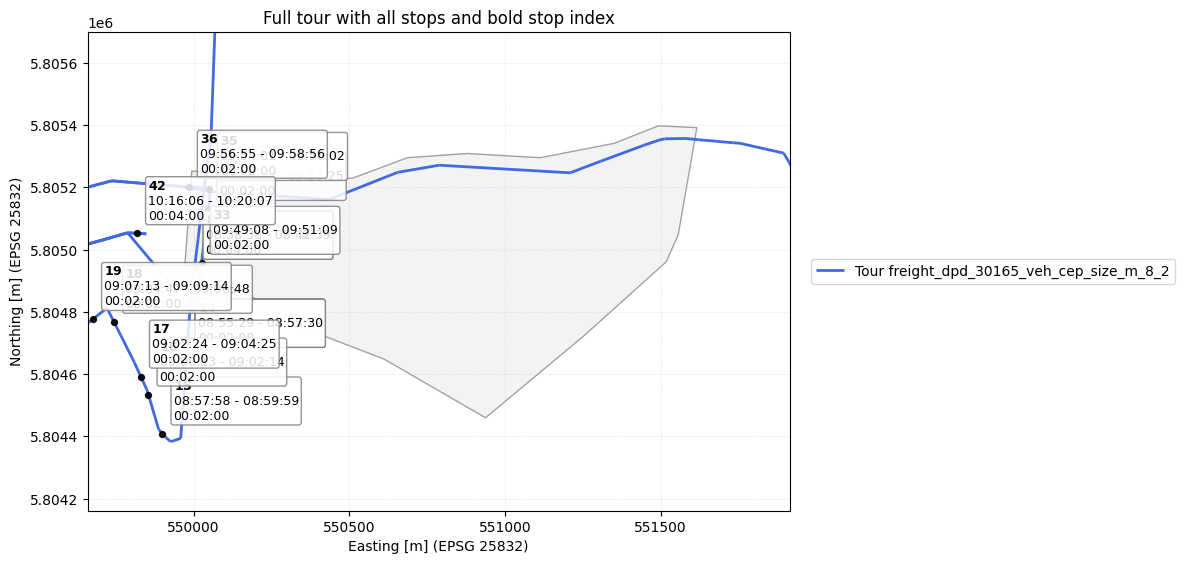

In [38]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

def fmt_hms(sec):
    try:
        s = max(0, int(round(float(sec))))
    except Exception:
        return "00:00:00"
    h = s // 3600
    m = (s % 3600) // 60
    s = s % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

assert "timelines_by_vehicle" in globals(), "timelines_by_vehicle missing."
assert "vissim_area" in globals(), "vissim_area required."
assert "network" in globals(), "network required."
assert "vehicle_tour" in globals(), "vehicle_tour required."

tours_df = result[result["stopped_in_any_cell"] == True].copy()
if tours_df.empty:
    raise ValueError("No vehicles with stopped_in_any_cell == True.")
one_vehicle_id = tours_df["vehicle_id"].iloc[0]
tour_key = one_vehicle_id

link_geometry = network.set_index("link_id")["geometry"].to_dict()
link_ids = vehicle_tour.get(tour_key, [])
seg_geoms = [link_geometry.get(lid) for lid in link_ids if link_geometry.get(lid) is not None]
tour_lines_gdf = gpd.GeoDataFrame({"idx": range(len(seg_geoms))}, geometry=seg_geoms, crs=network.crs)

tl = timelines_by_vehicle[one_vehicle_id].copy()

# ensure we have a per-stop index
if "stop_index" not in tl.columns:
    tl = tl.sort_values(["start_time_s","end_time_s"]).reset_index(drop=True)
    tl["stop_index"] = tl.index

# compute centroids if missing
if not {"x","y"}.issubset(tl.columns):
    xs, ys = [], []
    for lid in tl["link_id"]:
        g = link_geometry.get(lid)
        if g is None:
            xs.append(None); ys.append(None)
        else:
            c = g.centroid
            xs.append(c.x); ys.append(c.y)
    tl["x"] = xs
    tl["y"] = ys

# fix start/end if needed and subtract 1s
bad = tl["end_time_s"] <= tl["start_time_s"]
if bad.any():
    tl.loc[bad, ["start_time_s", "end_time_s"]] = tl.loc[bad, ["end_time_s", "start_time_s"]].values

tl["duration_s"] = (tl["end_time_s"] - tl["start_time_s"] - 1).clip(lower=0)
tl["start_time"] = pd.to_datetime(tl["start_time_s"], unit="s").dt.strftime("%H:%M:%S")
tl["end_time"]   = pd.to_datetime(tl["end_time_s"],   unit="s").dt.strftime("%H:%M:%S")
tl["duration_hms"] = tl["duration_s"].apply(fmt_hms)

stops_all_gdf = gpd.GeoDataFrame(
    {
        "vehicle_id": [one_vehicle_id] * len(tl),
        "stop_index": tl["stop_index"].astype(int),
        "start_time": tl["start_time"],
        "end_time": tl["end_time"],
        "duration_hms": tl["duration_hms"],
    },
    geometry=[Point(xy) if pd.notna(xy[0]) and pd.notna(xy[1]) else None for xy in zip(tl["x"], tl["y"])],
    crs=network.crs
).dropna(subset=["geometry"])

# CRS vereinheitlichen
if tour_lines_gdf.crs is None:
    tour_lines_gdf = tour_lines_gdf.set_crs(vissim_area.crs, allow_override=True)
if stops_all_gdf.crs is None:
    stops_all_gdf = stops_all_gdf.set_crs(vissim_area.crs, allow_override=True)
if str(tour_lines_gdf.crs) != str(vissim_area.crs):
    tour_lines_gdf = tour_lines_gdf.to_crs(vissim_area.crs)
if str(stops_all_gdf.crs) != str(vissim_area.crs):
    stops_all_gdf = stops_all_gdf.to_crs(vissim_area.crs)

# Plot
fig, ax = plt.subplots(figsize=(12, 11))
vissim_area.plot(ax=ax, facecolor="#dddddd", edgecolor="black", alpha=0.35, linewidth=1.0, zorder=1)
tour_lines_gdf.plot(ax=ax, color="royalblue", linewidth=2.0, zorder=2, label=f"Tour {one_vehicle_id}")
stops_all_gdf.plot(ax=ax, marker="o", markersize=18, color="black", alpha=0.9, zorder=3)

# annotation with bold stop_index in the box (MathText)
for _, r in stops_all_gdf.iterrows():
    idx = int(r["stop_index"])
    # first line bold number, then normal lines
    txt = r"$\bf{" + str(idx) + r"}$" + f"\n{r['start_time']} - {r['end_time']}\n{r['duration_hms']}"
    ax.annotate(
        txt,
        xy=(r.geometry.x, r.geometry.y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.85),
        ha="left", va="bottom"
    )

# Zoom auf Zellen
minx, miny, maxx, maxy = vissim_area.total_bounds
pad = 300
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_xlabel("Easting [m] (EPSG 25832)")
ax.set_ylabel("Northing [m] (EPSG 25832)")
ax.set_title("Full tour with all stops and bold stop index")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.tight_layout()
plt.show()




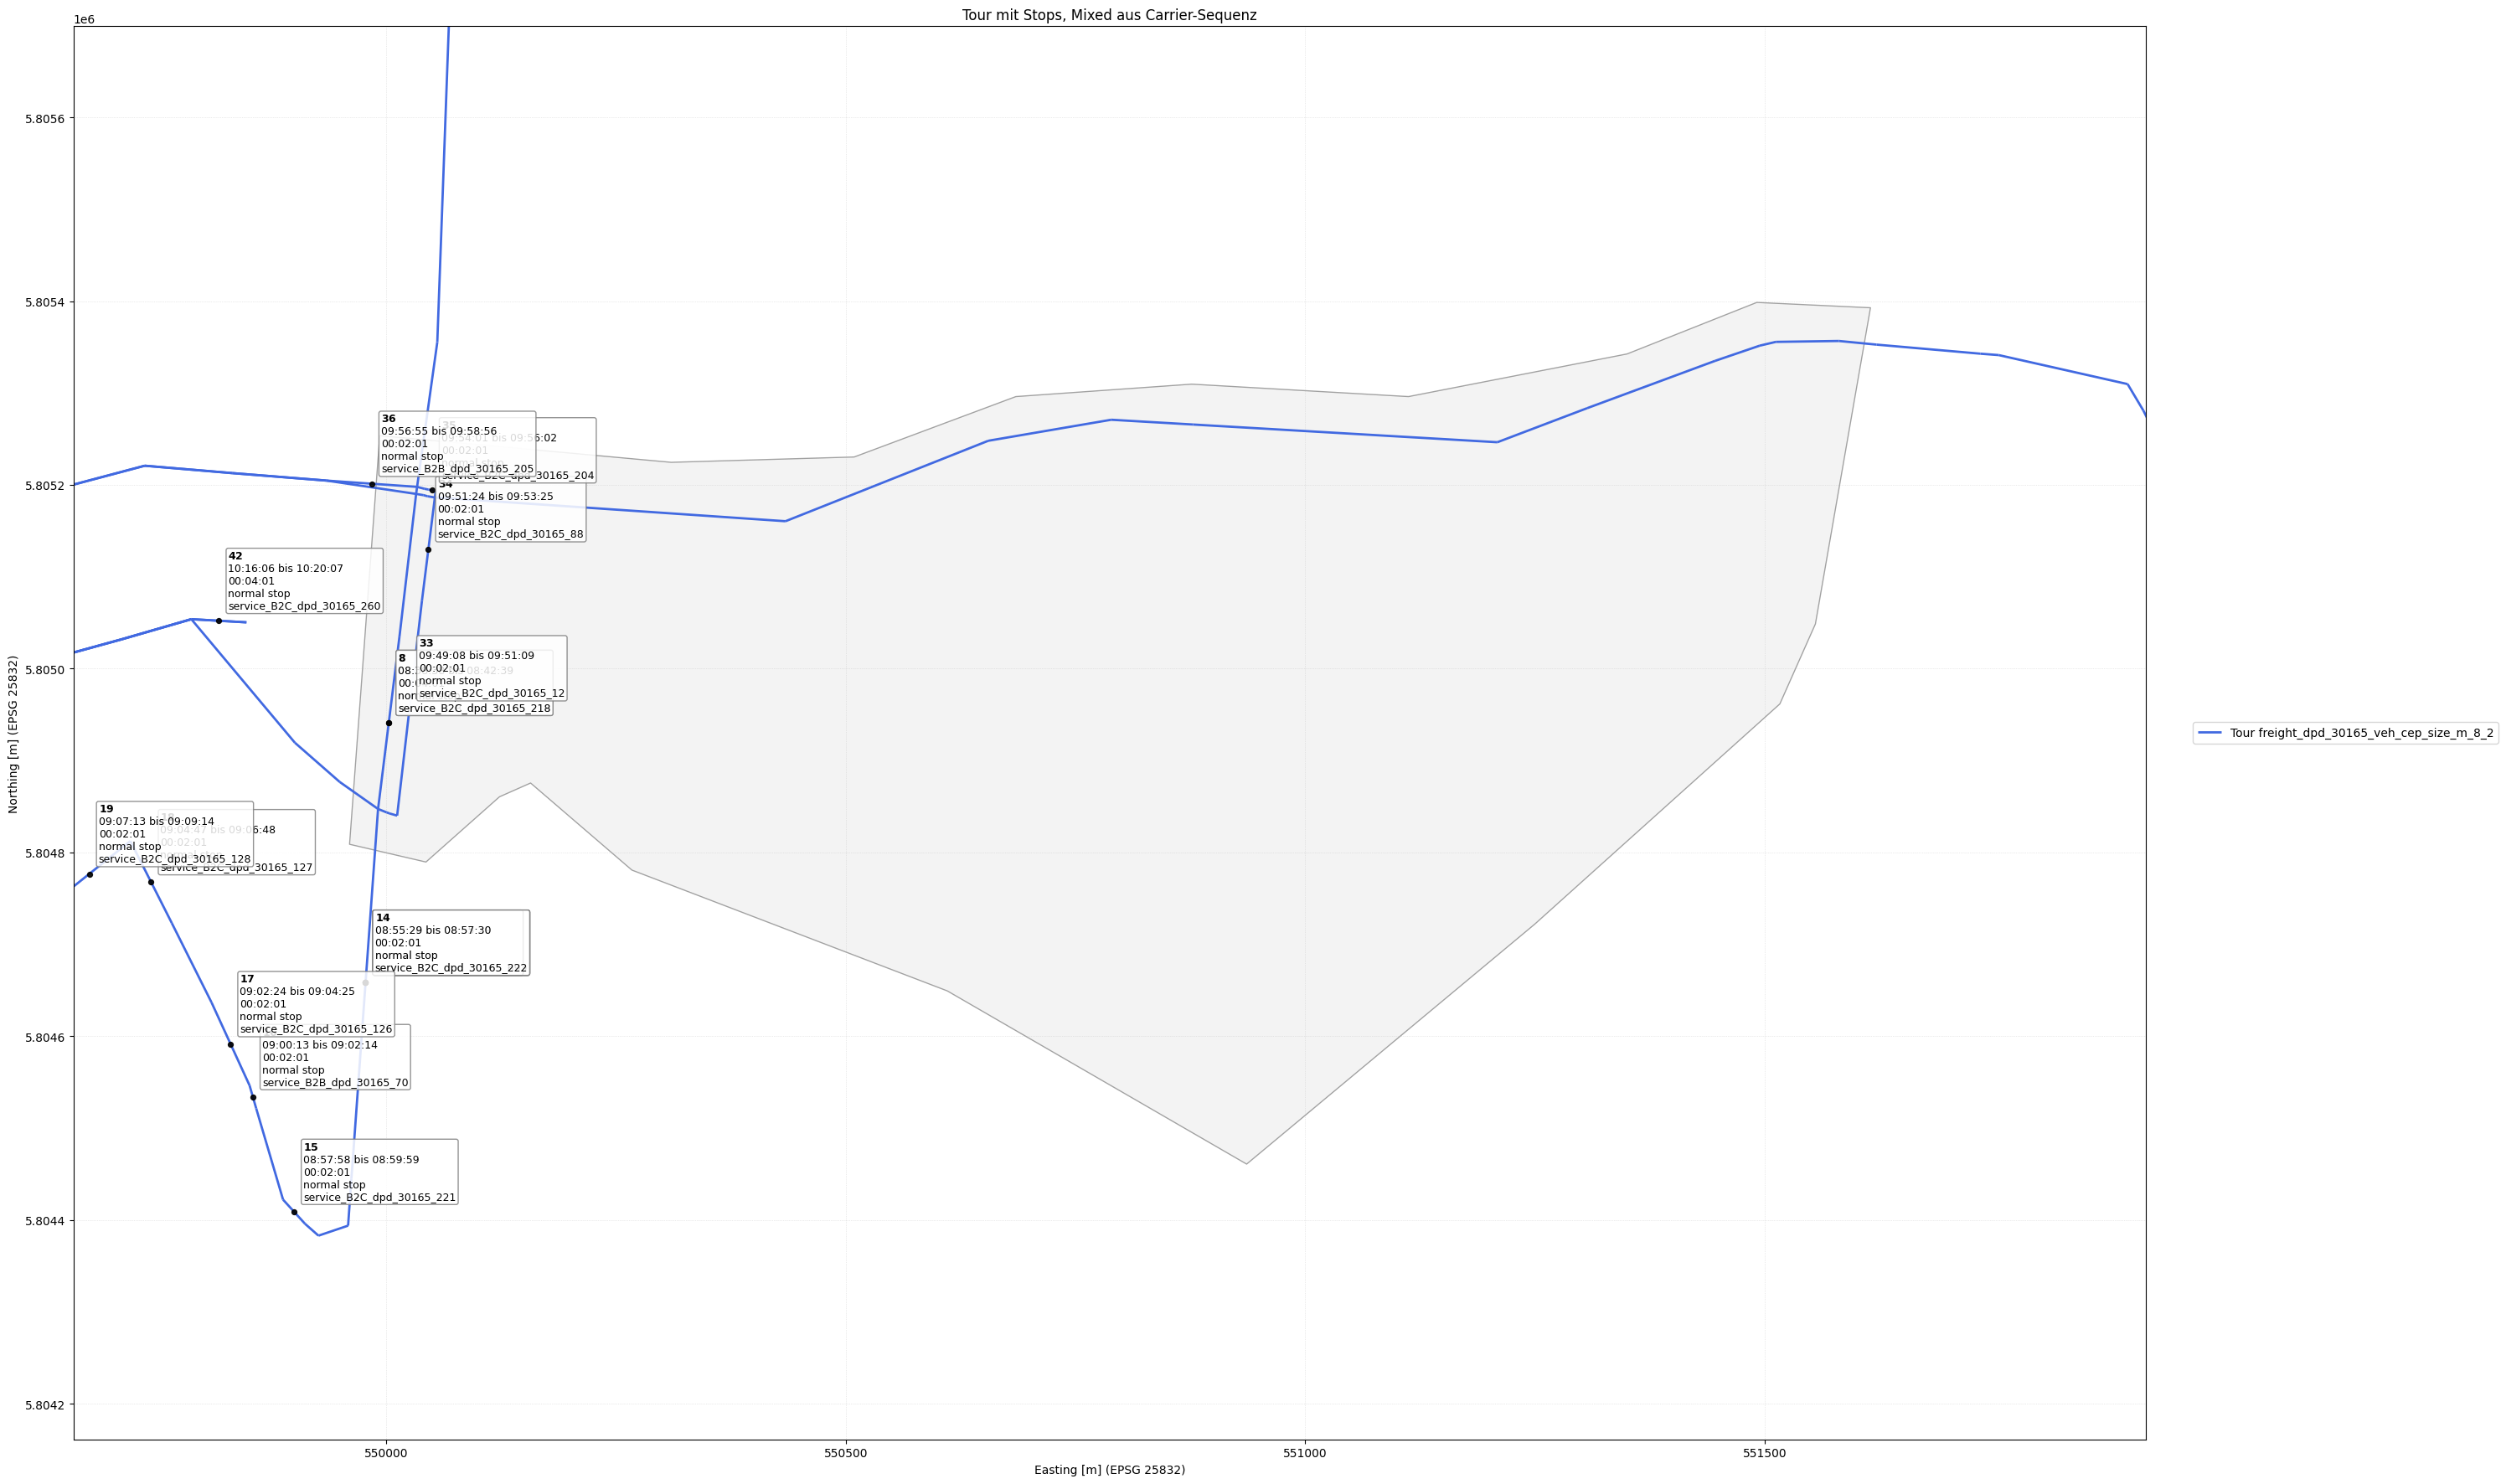

In [39]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import json
import string
from shapely.geometry import Point

def fmt_hms(sec):
    try:
        s = max(0, int(round(float(sec))))
    except Exception:
        return "00:00:00"
    h = s // 3600
    m = (s % 3600) // 60
    s = s % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

assert "timelines_by_vehicle" in globals(), "timelines_by_vehicle missing."
assert "vissim_area" in globals(), "vissim_area required."
assert "network" in globals(), "network required."
assert "vehicle_tour" in globals(), "vehicle_tour required."
assert "result" in globals(), "result DataFrame required."
assert "attach_service_sequence_to_timeline" in globals(), "attach_service_sequence_to_timeline missing."
assert "vehicle_seq" in globals(), "vehicle_seq missing. Build it with build_vehicle_service_sequence_from_carriers(carriers)."

tours_df = result[result["stopped_in_any_cell"] == True].copy()
if tours_df.empty:
    raise ValueError("No vehicles with stopped_in_any_cell == True.")

one_vehicle_id = tours_df["vehicle_id"].iloc[0]
tour_key = one_vehicle_id

link_geometry = network.set_index("link_id")["geometry"].to_dict()
link_ids = vehicle_tour.get(tour_key, [])
seg_geoms = [link_geometry.get(lid) for lid in link_ids if link_geometry.get(lid) is not None]
tour_lines_gdf = gpd.GeoDataFrame({"idx": range(len(seg_geoms))}, geometry=seg_geoms, crs=network.crs)

# Timeline holen und mit Carrier-Sequenz anreichern
tl = timelines_by_vehicle[one_vehicle_id].copy()
seq_df = vehicle_seq.get(one_vehicle_id)  # kommt aus build_vehicle_service_sequence_from_carriers
if seq_df is None or seq_df.empty:
    raise ValueError("No carrier service sequence for selected vehicle. Check vehicle_seq[vehicle_id].")

link_geom_map = network.set_index("link_id")["geometry"].to_dict()
tl = attach_service_sequence_to_timeline(tl, seq_df, link_geom_map=link_geom_map)

# Ab hier KEIN explode_mixed_services mehr aufrufen

# stop_index sicher
if "stop_index" not in tl.columns:
    tl = tl.sort_values(["start_time_s", "end_time_s"]).reset_index(drop=True)
    tl["stop_index"] = tl.index

# Zeiten
bad = tl["end_time_s"] <= tl["start_time_s"]
if bad.any():
    tl.loc[bad, ["start_time_s", "end_time_s"]] = tl.loc[bad, ["end_time_s", "start_time_s"]].values

tl["duration_s"] = (tl["end_time_s"] - tl["start_time_s"]).clip(lower=0)
tl["start_time"] = pd.to_datetime(tl["start_time_s"], unit="s").dt.strftime("%H:%M:%S")
tl["end_time"]   = pd.to_datetime(tl["end_time_s"],   unit="s").dt.strftime("%H:%M:%S")
tl["duration_hms"] = tl["duration_s"].apply(fmt_hms)

# Defaults für Felder aus attach
for col, default in {
    "is_mixed_child": False,
    "service_id": "",
    "service_id_child": "",
    "x_child": np.nan,
    "y_child": np.nan,
}.items():
    if col not in tl.columns:
        tl[col] = default

# Label
if "stop_label" not in tl.columns or tl["stop_label"].isna().any():
    tl["stop_label"] = tl["stop_index"].astype(int).astype(str)

# Koordinate: mixed Kinderkoordinate sonst x y sonst Linkcentroid
if "x" not in tl.columns:
    tl["x"] = np.nan
    tl["y"] = np.nan

use_child = tl["is_mixed_child"].fillna(False) & tl["x_child"].notna() & tl["y_child"].notna()
tl.loc[use_child, ["x", "y"]] = tl.loc[use_child, ["x_child", "y_child"]].values

missing_xy = tl["x"].isna() | tl["y"].isna()
if missing_xy.any():
    xs, ys = [], []
    for lid in tl.loc[missing_xy, "link_id"]:
        g = link_geometry.get(lid)
        if g is None:
            xs.append(np.nan); ys.append(np.nan)
        else:
            c = g.centroid
            xs.append(c.x); ys.append(c.y)
    tl.loc[missing_xy, "x"] = xs
    tl.loc[missing_xy, "y"] = ys

# Stop-Typ und Serviceanzeige
tl["stop_type"] = np.where(tl["is_mixed_child"].fillna(False), "mixed stop", "normal stop")
service_label = np.where(
    tl["is_mixed_child"].fillna(False) & tl["service_id_child"].astype(str).str.len().gt(0),
    tl["service_id_child"].astype(str),
    tl["service_id"].astype(str),
)

# Stops GDF
stops_all_gdf = gpd.GeoDataFrame(
    {
        "vehicle_id": one_vehicle_id,
        "stop_index": tl["stop_index"].astype(int),
        "stop_label": tl["stop_label"].astype(str),
        "start_time": tl["start_time"],
        "end_time": tl["end_time"],
        "duration_hms": tl["duration_hms"],
        "service_id": service_label,
        "is_mixed_child": tl["is_mixed_child"].fillna(False).astype(bool),
        "stop_type": tl["stop_type"],
    },
    geometry=[Point(xy) if pd.notna(xy[0]) and pd.notna(xy[1]) else None for xy in tl[["x","y"]].to_numpy()],
    crs=network.crs,
).dropna(subset=["geometry"])

# CRS angleichen
if tour_lines_gdf.crs is None:
    tour_lines_gdf = tour_lines_gdf.set_crs(vissim_area.crs, allow_override=True)
if stops_all_gdf.crs is None:
    stops_all_gdf = stops_all_gdf.set_crs(vissim_area.crs, allow_override=True)
if str(tour_lines_gdf.crs) != str(vissim_area.crs):
    tour_lines_gdf = tour_lines_gdf.to_crs(vissim_area.crs)
if str(stops_all_gdf.crs) != str(vissim_area.crs):
    stops_all_gdf = stops_all_gdf.to_crs(vissim_area.crs)

# Plot
fig, ax = plt.subplots(figsize=(30, 30))
vissim_area.plot(ax=ax, facecolor="#dddddd", edgecolor="black", alpha=0.35, linewidth=1.0, zorder=1)
tour_lines_gdf.plot(ax=ax, color="royalblue", linewidth=2.0, zorder=2, label=f"Tour {one_vehicle_id}")
stops_all_gdf.plot(ax=ax, marker="o", markersize=18, color="black", alpha=0.9, zorder=3)

for _, r in stops_all_gdf.iterrows():
    lbl = r["stop_label"]
    txt = (
        r"$\bf{" + str(lbl) + r"}$"
        + f"\n{r['start_time']} bis {r['end_time']}"
        + f"\n{r['duration_hms']}"
        + f"\n{r['stop_type']}"
        + (f"\n{r['service_id']}" if str(r['service_id']).strip() else "")
    )
    ax.annotate(
        txt,
        xy=(r.geometry.x, r.geometry.y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.85),
        ha="left", va="bottom"
    )

minx, miny, maxx, maxy = vissim_area.total_bounds
pad = 300
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_xlabel("Easting [m] (EPSG 25832)")
ax.set_ylabel("Northing [m] (EPSG 25832)")
ax.set_title("Tour mit Stops, Mixed aus Carrier-Sequenz")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.tight_layout()
plt.show()


In [40]:
# Interactive HTML export for tours and stops using Folium.
# - Shows selected tour as a polyline (from link geometries)
# - Shows all stops as clickable points with popup and hover tooltip
# - Provides layer toggles and a vehicle picker control
#
# Prerequisites in memory:
# - result: DataFrame with ["vehicle_id","stopped_in_any_cell","coords_list"]
# - vehicle_tour: dict vehicle_id -> list of link_ids
# - network: GeoDataFrame with ["link_id","geometry"] in projected CRS (e.g., EPSG:25832)
# - timelines_by_vehicle: dict vehicle_id -> DataFrame with ["link_id","start_time_s","end_time_s"] and optional ["x","y","stop_index"]
# - vissim_area: GeoDataFrame with cells polygons
# Optional:
# - attach_service_sequence_to_timeline function and vehicle_seq dict for mixed services

import folium
from folium.plugins import Fullscreen, MarkerCluster
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, LineString, MultiLineString
from branca.element import MacroElement, Element
from jinja2 import Template

# ---------------- helpers ----------------

def to_wgs84(gdf, default_crs="EPSG:25832"):
    if gdf is None or len(gdf) == 0:
        return gdf
    if gdf.crs is None:
        gdf = gdf.set_crs(default_crs, allow_override=True)
    return gdf.to_crs(epsg=4326)

def fmt_hms(sec):
    try:
        s = max(0, int(round(float(sec))))
    except Exception:
        return "00:00:00"
    h = s // 3600
    m = (s % 3600) // 60
    s = s % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

def ensure_stop_fields(df):
    d = df.copy()
    # times and duration
    if not {"start_time_s","end_time_s"}.issubset(d.columns):
        raise ValueError("Timeline needs columns: start_time_s, end_time_s")
    bad = d["end_time_s"] <= d["start_time_s"]
    if bad.any():
        d.loc[bad, ["start_time_s", "end_time_s"]] = d.loc[bad, ["end_time_s", "start_time_s"]].values
    d["duration_s"] = (d["end_time_s"] - d["start_time_s"]).clip(lower=0)
    d["start_time"] = pd.to_datetime(d["start_time_s"], unit="s").dt.strftime("%H:%M:%S")
    d["end_time"]   = pd.to_datetime(d["end_time_s"],   unit="s").dt.strftime("%H:%M:%S")
    d["duration_hms"] = d["duration_s"].apply(fmt_hms)
    # stop index and label
    if "stop_index" not in d.columns:
        d = d.sort_values(["start_time_s","end_time_s"]).reset_index(drop=True)
        d["stop_index"] = d.index.astype(int)
    # service fields
    for col, default in {
        "is_mixed_child": False,
        "service_id": "",
        "service_id_child": "",
        "x_child": np.nan, "y_child": np.nan,
    }.items():
        if col not in d.columns:
            d[col] = default
    return d

def choose_xy(df, link_geom_map):
    d = df.copy()
    # base x,y if missing
    if "x" not in d.columns:
        d["x"] = np.nan; d["y"] = np.nan
    # prefer child coords for mixed rows
    use_child = d["is_mixed_child"].fillna(False) & d["x_child"].notna() & d["y_child"].notna()
    d.loc[use_child, ["x","y"]] = d.loc[use_child, ["x_child","y_child"]].values
    # fill remaining from link centroid
    missing = d["x"].isna() | d["y"].isna()
    if missing.any():
        xs, ys = [], []
        for lid in d.loc[missing, "link_id"]:
            g = link_geom_map.get(lid)
            if g is None:
                xs.append(np.nan); ys.append(np.nan)
            else:
                c = g.centroid
                xs.append(c.x); ys.append(c.y)
        d.loc[missing, "x"] = xs; d.loc[missing, "y"] = ys
    return d

def build_stops_gdf_from_timeline(veh_id, tl_df, link_geom_map, default_crs="EPSG:25832"):
    # ensure core fields
    d = ensure_stop_fields(tl_df)
    # choose coordinates with mixed preference
    d = choose_xy(d, link_geom_map)
    # stop_type and service label
    d["stop_type"] = np.where(d["is_mixed_child"].fillna(False), "mixed stop", "normal stop")
    d["service_label"] = np.where(
        d["is_mixed_child"].fillna(False) & d["service_id_child"].astype(str).str.len().gt(0),
        d["service_id_child"].astype(str),
        d["service_id"].astype(str),
    )
    # geodataframe
    gdf = gpd.GeoDataFrame(
        {
            "vehicle_id": veh_id,
            "stop_index": d["stop_index"].astype(int),
            "link_id": d["link_id"].astype(str),
            "start_time": d["start_time"],
            "end_time": d["end_time"],
            "duration_hms": d["duration_hms"],
            "stop_type": d["stop_type"].astype(str),
            "service_id": d["service_label"].astype(str),
            "is_mixed_child": d["is_mixed_child"].fillna(False).astype(bool),
        },
        geometry=[Point(xy) if pd.notna(xy[0]) and pd.notna(xy[1]) else None for xy in d[["x","y"]].to_numpy()],
        crs=network.crs if hasattr(network, "crs") and network.crs else default_crs
    ).dropna(subset=["geometry"])
    return gdf

def polyline_coords_from_links(link_ids, link_geom_map):
    coords = []
    for lid in link_ids:
        geom = link_geom_map.get(lid)
        if geom is None:
            continue
        if isinstance(geom, LineString):
            coords.extend(list(geom.coords))
        elif isinstance(geom, MultiLineString):
            for ls in geom.geoms:
                coords.extend(list(ls.coords))
    dedup, last = [], None
    for pt in coords:
        if last is None or pt != last:
            dedup.append(pt); last = pt
    return dedup

# ---------------- inputs and checks ----------------

tours_df_sel = result[result["stopped_in_any_cell"] == True].copy()
if tours_df_sel.empty:
    raise ValueError("No vehicles with stopped_in_any_cell == True.")
vehicle_ids = tours_df_sel["vehicle_id"].tolist()

if "link_id" not in network.columns or "geometry" not in network.columns:
    raise KeyError("network must have columns 'link_id' and 'geometry'.")
link_geom_map = network.set_index("link_id")["geometry"].to_dict()

# map center from cells
cells_wgs = to_wgs84(vissim_area)
minx, miny, maxx, maxy = cells_wgs.total_bounds
center_lat = (miny + maxy) / 2.0
center_lon = (minx + maxx) / 2.0

# ---------------- map ----------------

m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="cartodbpositron", control_scale=True)
Fullscreen().add_to(m)

# CSS: square number badges (ASCII only)
m.get_root().header.add_child(Element("""
<style>
.stop-badge{
  width:24px; height:24px;
  background:#ffffff;
  border:2px solid #2b6cb0;
  border-radius:4px;
  font-family: monospace;
  font-weight:700;
  font-size:12px;
  line-height:20px; /* 24 - 2*2 */
  text-align:center;
  color:#000000;
  box-shadow:0 1px 2px rgba(0,0,0,0.35);
  user-select:none;
  pointer-events:none; /* allow marker to receive clicks */
}
</style>
"""))

# cells layer
cells_group = folium.FeatureGroup(name="Cells", show=True)
for _, row in cells_wgs.iterrows():
    gj = folium.GeoJson(
        data=row.geometry.__geo_interface__,
        name=str(row.get("Zelle","Cell")),
        style_function=lambda x: {"color":"#555555","weight":1.0,"fillColor":"#cccccc","fillOpacity":0.25},
        highlight_function=lambda x: {"weight":2, "color":"#000000"}
    )
    gj.add_to(cells_group)
cells_group.add_to(m)

# combined groups
all_tours_group = folium.FeatureGroup(name="All tours", show=True).add_to(m)
all_stops_group = folium.FeatureGroup(name="All stops", show=False).add_to(m)

# add per-vehicle layers
for veh_id in vehicle_ids:
    if veh_id not in timelines_by_vehicle:
        continue
    link_ids = vehicle_tour.get(veh_id, [])
    if not isinstance(link_ids, list) or len(link_ids) == 0:
        continue

    vg = folium.FeatureGroup(name=f"Tour {veh_id}", show=False).add_to(m)
    sg = folium.FeatureGroup(name=f"Stops {veh_id}", show=False).add_to(m)

    # tour polyline
    line_xy = polyline_coords_from_links(link_ids, link_geom_map)
    if len(line_xy) >= 2:
        line_gdf = gpd.GeoDataFrame(geometry=[LineString(line_xy)], crs=network.crs if network.crs else "EPSG:25832")
        line_wgs = to_wgs84(line_gdf).geometry.iloc[0]
        path = [(lat, lon) for lon, lat in zip(*zip(*list(line_wgs.coords)))]
        folium.PolyLine(locations=path, color="#2b6cb0", weight=3, opacity=0.9).add_to(vg)
        folium.PolyLine(locations=path, color="#2b6cb0", weight=2, opacity=0.5).add_to(all_tours_group)

    # timeline and optional enrichment for mixed services
    base_tl = timelines_by_vehicle[veh_id].copy()
    if "attach_service_sequence_to_timeline" in globals() and "vehicle_seq" in globals():
        seq_df = vehicle_seq.get(veh_id, None)
        if seq_df is not None and not getattr(seq_df, "empty", True):
            base_tl = attach_service_sequence_to_timeline(base_tl, seq_df, link_geom_map=link_geom_map)

    # stops
    stops_gdf = build_stops_gdf_from_timeline(veh_id, base_tl, link_geom_map)
    stops_wgs = to_wgs84(stops_gdf)

    # cluster containers for this vehicle and for the "all stops" collection
    cluster_sg = MarkerCluster(spiderfyOnMaxZoom=True,
                               disableClusteringAtZoom=18,
                               showCoverageOnHover=False).add_to(sg)
    cluster_all = MarkerCluster(spiderfyOnMaxZoom=True,
                                disableClusteringAtZoom=18,
                                showCoverageOnHover=False).add_to(all_stops_group)

    for _, r in stops_wgs.iterrows():
        lat, lon = r.geometry.y, r.geometry.x
        idx_num = int(r["stop_index"])

        # tooltip and popup
        t_service = f" | {r['service_id']}" if str(r.get("service_id","")).strip() else ""
        tooltip = folium.Tooltip(
            f"#{idx_num} {r['start_time']} bis {r['end_time']} ({r['duration_hms']})"
            + f" | {r['stop_type']}{t_service}"
        )
        popup_html = f"""
        <div style='font-family:monospace'>
        <b>Vehicle:</b> {veh_id}<br/>
        <b>Stop index:</b> {idx_num}<br/>
        <b>Start:</b> {r['start_time']}<br/>
        <b>End:</b> {r['end_time']}<br/>
        <b>Duration:</b> {r['duration_hms']}<br/>
        <b>Type:</b> {r['stop_type']}<br/>
        <b>Link:</b> {r['link_id']}<br/>
        <b>Service:</b> {r.get('service_id','')}
        </div>
        """

        # square number badge as DivIcon
        label_html = f"<div class='stop-badge'>{idx_num}</div>"

        # vehicle-specific cluster
        folium.Marker(
            location=(lat, lon),
            icon=folium.DivIcon(html=label_html, icon_size=(24,24), icon_anchor=(12,12), class_name=""),
            tooltip=tooltip,
            popup=folium.Popup(popup_html, max_width=360)
        ).add_to(cluster_sg)

        # all-stops cluster
        folium.Marker(
            location=(lat, lon),
            icon=folium.DivIcon(html=label_html, icon_size=(24,24), icon_anchor=(12,12), class_name=""),
            tooltip=tooltip,
            popup=folium.Popup(popup_html, max_width=360)
        ).add_to(cluster_all)

    vg.add_to(m)
    sg.add_to(m)

# bounds and controls
m.fit_bounds([[miny, minx], [maxy, maxx]])
folium.LayerControl(collapsed=False).add_to(m)

# simple toggle button for "All stops" (ASCII only)
toggle_js = """
{% macro script(this, kwargs) %}
var btn = L.control({position: 'topleft'});
btn.onAdd = function (map) {
    var div = L.DomUtil.create('div', 'leaflet-bar leaflet-control leaflet-control-custom');
    div.style.backgroundColor = 'white';
    div.style.padding = '6px';
    div.style.cursor = 'pointer';
    div.title = 'Show/Hide All Stops';
    div.innerHTML = 'Stops';
    var visible = false;
    div.onclick = function(){
        if(visible){
            map.removeLayer(allStopsLayer);
            visible = false;
            div.style.opacity = 0.7;
        } else {
            map.addLayer(allStopsLayer);
            visible = true;
            div.style.opacity = 1.0;
        }
    };
    return div;
};
btn.addTo({{this._parent.get_name()}});
var allStopsLayer = null;
{{this._parent.get_name()}}.eachLayer(function(layer){
    if(layer && layer.options && layer.options.name && layer.options.name === "All stops"){
        allStopsLayer = layer;
    }
});
{% endmacro %}
"""
class ToggleAllStopsButton(MacroElement):
    def __init__(self, folium_map):
        super().__init__()
        self._name = 'ToggleAllStopsButton'
        self._parent = folium_map
        self._template = Template(toggle_js)

ToggleAllStopsButton(m).add_to(m)

# Vehicle picker control
vehicle_picker_tpl = """
{% macro script(this, kwargs) %}
(function(){
  var map = {{this._parent.get_name()}};
  var layerByName = {};
  map.eachLayer(function(layer){
    if (layer && layer.options && layer.options.name){
      layerByName[layer.options.name] = layer;
    }
  });
  var ctl = L.control({position: 'topright'});
  ctl.onAdd = function(map){
    var div = L.DomUtil.create('div', 'leaflet-bar leaflet-control leaflet-control-custom');
    div.style.backgroundColor = 'white';
    div.style.padding = '10px';
    div.style.minWidth = '220px';
    div.style.boxShadow = '0 0 6px rgba(0,0,0,0.3)';
    div.style.font = '12px Arial, sans-serif';
    var title = L.DomUtil.create('div', '', div);
    title.innerHTML = '<b>Vehicle picker</b>';
    var sel = L.DomUtil.create('select', '', div);
    sel.style.width = '100%';
    sel.style.marginTop = '6px';
    sel.id = 'veh_select';
    var opt0 = document.createElement('option');
    opt0.value = ''; opt0.text = 'Select vehicle';
    sel.appendChild(opt0);
    var vehicles = {{ this.vehicles | tojson }};
    vehicles.forEach(function(v){
      var o = document.createElement('option');
      o.value = v; o.text = v;
      sel.appendChild(o);
    });
    var br0 = L.DomUtil.create('div', '', div); br0.style.height = '6px';
    var cbTour = L.DomUtil.create('input', '', div);
    cbTour.type = 'checkbox'; cbTour.id = 'cb_tour';
    var lblTour = L.DomUtil.create('label', '', div);
    lblTour.htmlFor = 'cb_tour'; lblTour.style.marginLeft = '4px';
    lblTour.innerHTML = 'Show tour';
    var br1 = L.DomUtil.create('div', '', div); br1.style.height = '4px';
    var cbStops = L.DomUtil.create('input', '', div);
    cbStops.type = 'checkbox'; cbStops.id = 'cb_stops';
    var lblStops = L.DomUtil.create('label', '', div);
    lblStops.htmlFor = 'cb_stops'; lblStops.style.marginLeft = '4px';
    lblStops.innerHTML = 'Show stops';

    function hideAll(){
      Object.keys(layerByName).forEach(function(k){
        if (k.startsWith('Tour ') || k.startsWith('Stops ')){
          if (map.hasLayer(layerByName[k])){
            map.removeLayer(layerByName[k]);
          }
        }
      });
    }
    function apply(){
      hideAll();
      var v = sel.value;
      if (!v) return;
      var tname = 'Tour ' + v;
      var sname = 'Stops ' + v;
      if (cbTour.checked && layerByName[tname]) map.addLayer(layerByName[tname]);
      if (cbStops.checked && layerByName[sname]) map.addLayer(layerByName[sname]);
    }
    sel.onchange = apply; cbTour.onchange = apply; cbStops.onchange = apply;
    L.DomEvent.disableClickPropagation(div);
    L.DomEvent.disableScrollPropagation(div);
    return div;
  };
  ctl.addTo(map);
})();
{% endmacro %}
"""
class VehiclePicker(MacroElement):
    def __init__(self, folium_map, vehicles):
        super().__init__()
        self._name = 'VehiclePicker'
        self._parent = folium_map
        self.vehicles = vehicles
        self._template = Template(vehicle_picker_tpl)

VehiclePicker(m, vehicle_ids).add_to(m)

# save
out_path = "our_map_3.html"
m.save(out_path)
print(f"Map saved to: {out_path}")


Map saved to: our_map_3.html


In [46]:
stops_gdf

,vehicle_id,stop_index,link_id,start_time,end_time,duration_hms,geometry
0,freight_dpd_30165_veh_cep_size_m_8_2,0,1032159-945644-405796,08:13:26,08:15:27,00:02:01,POINT (549531.439 5806940.145)
1,freight_dpd_30165_veh_cep_size_m_8_2,1,3511013,08:17:08,08:19:09,00:02:01,POINT (549664.908 5806517.738)
2,freight_dpd_30165_veh_cep_size_m_8_2,2,3493947,08:20:35,08:22:36,00:02:01,POINT (549770.048 5806468.804)
3,freight_dpd_30165_veh_cep_size_m_8_2,3,1378437,08:23:17,08:25:18,00:02:01,POINT (549740.848 5806367.47)
4,freight_dpd_30165_veh_cep_size_m_8_2,4,3493953,08:27:20,08:29:21,00:02:01,POINT (549888.457 5806196.054)
...,...,...,...,...,...,...,...
70,freight_dpd_30165_veh_cep_size_m_8_2,70,1450460,11:39:59,11:42:00,00:02:01,POINT (548820.84 5805596.381)
71,freight_dpd_30165_veh_cep_size_m_8_2,71,2752217,11:44:13,11:48:14,00:04:01,POINT (549350.556 5805287.581)
72,freight_dpd_30165_veh_cep_size_m_8_2,72,2954044,11:48:38,11:52:39,00:04:01,POINT (549472.782 5805184.082)
73,freight_dpd_30165_veh_cep_size_m_8_2,73,2954044,11:52:39,11:54:40,00:02:01,POINT (549472.782 5805184.082)


In [55]:
# ==== Folium-HTML: Tours + Stops mit eckigen Index-Badges, Gradient-Route
# ==== und Mixed-Stop-Koordinaten (x_child/y_child) ====
# Erwartet: result, vehicle_tour, network, timelines_by_vehicle, vissim_area
# Optional: attach_service_sequence_to_timeline, vehicle_seq

import folium
from folium.plugins import Fullscreen
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, LineString, MultiLineString
from branca.element import MacroElement, Element
from jinja2 import Template
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ---------- Parameter ----------
GRADIENT_CMAP    = "cividis"    # z.B. 'viridis', 'plasma', 'RdYlGn'
GRADIENT_REVERSE = False
ROUTE_WIDTH      = 4
ROUTE_ALPHA      = 0.95
ALL_TOURS_COLOR  = "#2b6cb0"

    # --- Stops mit gleicher Link-ID und Koordinate entlang des Links verteilen (mit zufälliger, aber sortierter Streuung) ---
import numpy as np
from shapely.geometry import LineString

# Funktion: verteilt Stops entlang des Links, Reihenfolge bleibt erhalten, Abstände schwanken leicht

def distribute_stops_on_link(stops_gdf, links_gdf, link_id_col='link_id', geom_col='geometry', order_col='stop_index', seed=42, min_dist=50):
    stops_gdf = stops_gdf.copy()
    rng = np.random.default_rng(seed)
    grouped = stops_gdf.groupby([link_id_col, geom_col])
    for (link_id, geom), group in grouped:
        if len(group) > 1:
            link_geom = links_gdf.loc[links_gdf[link_id_col] == link_id, geom_col].values
            if len(link_geom) == 0:
                continue
            line = link_geom[0]
            n = len(group)
            idx_sorted = group.sort_values(order_col).index
            # Prüfe, ob genug Platz für Mindestabstand ist
            if line.length >= (n-1)*min_dist:
                # Gleichmäßige Abstände mit Mindestabstand
                start = (line.length - (n-1)*min_dist)/2 if line.length > (n-1)*min_dist else 0
                distances = [start + i*min_dist for i in range(n)]
                # Leichte Streuung (max ±15% von min_dist, aber nicht zu nah an Enden)
                jitter = rng.normal(0, 0.15*min_dist, n)
                distances = np.array(distances) + jitter
                # Sortiere, damit jeder Stop weiter als der vorherige ist
                distances = np.sort(np.clip(distances, 0.01*line.length, 0.99*line.length))
            else:
                # Link zu kurz: wie vorher, gleichmäßig mit Streuung, aber aufsteigend
                base = np.linspace(0.05, 0.95, n)
                jitter = rng.normal(0, 0.07, n)
                jitter = np.clip(jitter, -0.15, 0.15)
                positions = np.sort(np.clip(base + jitter, 0.01, 0.99))
                distances = positions * line.length
            new_points = [line.interpolate(d) for d in distances]
            stops_gdf.loc[idx_sorted, geom_col] = new_points
    return stops_gdf

# ---------- Helpers ----------
def to_wgs84(gdf, default_crs="EPSG:25832"):
    if gdf is None or len(gdf) == 0:
        return gdf
    if gdf.crs is None:
        gdf = gdf.set_crs(default_crs, allow_override=True)
    return gdf.to_crs(epsg=4326)

def fmt_hms(sec):
    try:
        s = max(0, int(round(float(sec))))
    except Exception:
        return "00:00:00"
    h = s // 3600; m = (s % 3600) // 60; s = s % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

def ensure_stop_fields(df):
    d = df.copy()
    # Zeiten/Dauer
    if not {"start_time_s","end_time_s"}.issubset(d.columns):
        raise ValueError("Timeline needs columns: start_time_s, end_time_s")
    bad = d["end_time_s"] <= d["start_time_s"]
    if bad.any():
        d.loc[bad, ["start_time_s","end_time_s"]] = d.loc[bad, ["end_time_s","start_time_s"]].values
    d["duration_s"]  = (d["end_time_s"] - d["start_time_s"]).clip(lower=0)
    d["start_time"]  = pd.to_datetime(d["start_time_s"], unit="s").dt.strftime("%H:%M:%S")
    d["end_time"]    = pd.to_datetime(d["end_time_s"],   unit="s").dt.strftime("%H:%M:%S")
    d["duration_hms"]= d["duration_s"].apply(fmt_hms)
    # Index
    if "stop_index" not in d.columns:
        d = d.sort_values(["start_time_s","end_time_s"]).reset_index(drop=True)
        d["stop_index"] = d.index.astype(int)
    # Basis-Koordinaten und Mixed-Felder
    if "x" not in d.columns: d["x"] = np.nan
    if "y" not in d.columns: d["y"] = np.nan
    for col, default in {"is_mixed_child": False, "x_child": np.nan, "y_child": np.nan}.items():
        if col not in d.columns:
            d[col] = default
    return d

def choose_xy(df, link_geom_map):
    d = df.copy()
    # 1) Kinderkoordinaten, wenn Mixed und vorhanden
    use_child = d.get("is_mixed_child", False)
    if isinstance(use_child, (pd.Series, np.ndarray)):
        use_child = use_child.fillna(False)
    else:
        use_child = False
    if "x_child" in d.columns and "y_child" in d.columns:
        mask_child = use_child & d["x_child"].notna() & d["y_child"].notna()
        if mask_child.any():
            d.loc[mask_child, ["x","y"]] = d.loc[mask_child, ["x_child","y_child"]].values
    # 2) Rest aus Link-Centroid füllen
    miss = d["x"].isna() | d["y"].isna()
    if miss.any():
        xs, ys = [], []
        for lid in d.loc[miss, "link_id"]:
            g = link_geom_map.get(lid)
            if g is None:
                xs.append(np.nan); ys.append(np.nan)
            else:
                c = g.centroid
                xs.append(c.x); ys.append(c.y)
        d.loc[miss, "x"] = xs; d.loc[miss, "y"] = ys
    return d

def build_stops_gdf_from_timeline(veh_id, tl_df, link_geom_map, default_crs="EPSG:25832"):
    d = ensure_stop_fields(tl_df)
    d = choose_xy(d, link_geom_map)
    gdf = gpd.GeoDataFrame(
        {
            "vehicle_id": veh_id,
            "stop_index": d["stop_index"].astype(int),
            "link_id": d["link_id"].astype(str),
            "start_time": d["start_time"],
            "end_time": d["end_time"],
            "duration_hms": d["duration_hms"],
        },
        geometry=[Point(xy) if pd.notna(xy[0]) and pd.notna(xy[1]) else None for xy in d[["x","y"]].to_numpy()],
        crs=network.crs if hasattr(network, "crs") and network.crs else default_crs
    ).dropna(subset=["geometry"])
    return gdf

def polyline_coords_from_links(link_ids, link_geom_map):
    coords = []
    for lid in link_ids:
        geom = link_geom_map.get(lid)
        if geom is None: 
            continue
        if isinstance(geom, LineString):
            coords.extend(list(geom.coords))
        elif isinstance(geom, MultiLineString):
            for ls in geom.geoms:
                coords.extend(list(ls.coords))
    dedup, last = [], None
    for pt in coords:
        if last is None or pt != last:
            dedup.append(pt); last = pt
    return dedup

def rgba_to_hex(rgba):
    r,g,b,a = rgba
    return mcolors.to_hex((r,g,b), keep_alpha=False)

def gradient_colors(n, cmap_name=GRADIENT_CMAP, reverse=GRADIENT_REVERSE):
    if n <= 1:
        return [rgba_to_hex(cm.get_cmap(cmap_name)(1.0 if not reverse else 0.0))]
    xs = np.linspace(0, 1, n)
    if reverse:
        xs = xs[::-1]
    cmap = cm.get_cmap(cmap_name)
    return [rgba_to_hex(cmap(x)) for x in xs]

def export_single_tour_to_csv_from_stops_gdf(veh_id, stops_gdf, out_dir="tours_csv_only_in_area_new"):
    os.makedirs(out_dir, exist_ok=True)
    # WGS84-Transformation
    gdf_wgs = stops_gdf.to_crs(epsg=4326) if stops_gdf.crs and stops_gdf.crs.to_epsg() != 4326 else stops_gdf.copy()
    df = gdf_wgs.drop(columns="geometry").copy()
    df["lon"] = gdf_wgs.geometry.x.round(6)
    df["lat"] = gdf_wgs.geometry.y.round(6)
    df["vehicle_id"] = veh_id
    # schöne Reihenfolge (nur vorhandene Spalten)
    wanted_cols = [
        "vehicle_id",
        "stop_index","stop_label","stop_type","is_mixed_child",
        "service_id","service_id_child",
        "start_time","end_time","duration_hms",
        "link_id","x","y","lon","lat"
    ]
    cols = [c for c in wanted_cols if c in df.columns]
    df_out = df[cols]
    # speichern
    fpath = os.path.join(out_dir, f"tour_{veh_id}.csv")
    df_out.to_csv(fpath, index=False, encoding="utf-8")
    print(f"{veh_id}: {len(df_out)} rows -> {fpath}")
    return fpath

# ---------- Inputs ----------
tours_df_sel = result[result["stopped_in_any_cell"] == True].copy()
if tours_df_sel.empty:
    raise ValueError("No vehicles with stopped_in_any_cell == True.")
vehicle_ids = tours_df_sel["vehicle_id"].tolist()

if "link_id" not in network.columns or "geometry" not in network.columns:
    raise KeyError("network must have columns 'link_id' and 'geometry'.")
link_geom_map = network.set_index("link_id")["geometry"].to_dict()

# ---------- Map ----------
cells_wgs = to_wgs84(vissim_area)
minx, miny, maxx, maxy = cells_wgs.total_bounds
center_lat = (miny + maxy) / 2.0
center_lon = (minx + maxx) / 2.0

m = folium.Map([center_lat, center_lon], zoom_start=13, tiles="cartodbpositron", control_scale=True)
Fullscreen().add_to(m)

# CSS für eckige, kompakte Index-Badges (Text läuft nicht über)
m.get_root().header.add_child(Element("""
<style>
.stop-square{
  display:inline-flex; align-items:center; justify-content:center;
  min-width:22px; height:22px; padding:0 4px;
  background:#ffffff; border:2px solid #2b6cb0; border-radius:4px;
  font: 12px/1 "Inter", system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif;
  font-weight:700; color:#1a202c;
  box-shadow:0 1px 2px rgba(0,0,0,0.25);
  white-space:nowrap;
  transform: translate(-12px, -30px);
  cursor: pointer;
  pointer-events: auto;   /* <— HIER: von none zu auto */
}
</style>
"""))

# Zellen
cells_group = folium.FeatureGroup(name="Cells", show=True)
for _, row in cells_wgs.iterrows():
    folium.GeoJson(
        data=row.geometry.__geo_interface__,
        name=str(row.get("Zelle", "Cell")),
        style_function=lambda x: {"color":"#4a4a4a","weight":1.0,"fillColor":"#cccccc","fillOpacity":0.20},
        highlight_function=lambda x: {"weight":2, "color":"#000000"}
    ).add_to(cells_group)
cells_group.add_to(m)

# Sammel-Layer
all_tours_group = folium.FeatureGroup(name="All tours", show=True).add_to(m)
all_stops_group = folium.FeatureGroup(name="All stops", show=False).add_to(m)

# ---------- pro Fahrzeug ----------
for veh_id in vehicle_ids:
    if veh_id not in timelines_by_vehicle:
        continue
    link_ids = vehicle_tour.get(veh_id, [])
    if not isinstance(link_ids, list) or len(link_ids) == 0:
        continue
    
    print("Plotting Tour for VehId: ", veh_id)

    vg = folium.FeatureGroup(name=f"Tour {veh_id}", show=False).add_to(m)
    sg = folium.FeatureGroup(name=f"Stops {veh_id}", show=False).add_to(m)

    # Route: segmentierter Farbverlauf + Übersicht
    line_xy = polyline_coords_from_links(link_ids, link_geom_map)
    if len(line_xy) >= 2:
        line_gdf = gpd.GeoDataFrame(geometry=[LineString(line_xy)], crs=network.crs if network.crs else "EPSG:25832")
        line_wgs = to_wgs84(line_gdf).geometry.iloc[0]
        path = [(lat, lon) for lon, lat in zip(*zip(*list(line_wgs.coords)))]

        segs     = [(path[i], path[i+1]) for i in range(len(path)-1)]
        seg_cols = gradient_colors(len(segs))
        for (p0, p1), col in zip(segs, seg_cols):
            folium.PolyLine(locations=[p0, p1], color=col, weight=ROUTE_WIDTH, opacity=ROUTE_ALPHA).add_to(vg)

        folium.PolyLine(locations=path, color=ALL_TOURS_COLOR, weight=2, opacity=0.45).add_to(all_tours_group)

    # Timeline ggf. mit Carrier-Sequenz anreichern (liefert is_mixed_child/x_child/y_child)
    base_tl = timelines_by_vehicle[veh_id].copy()
    if "attach_service_sequence_to_timeline" in globals() and "vehicle_seq" in globals():
        seq_df = vehicle_seq.get(veh_id, None)
        if seq_df is not None and not getattr(seq_df, "empty", True):
            base_tl = attach_service_sequence_to_timeline(base_tl, seq_df, link_geom_map=link_geom_map)

    # Stops mit Kinder-Koordinaten bevorzugt
    stops_gdf = build_stops_gdf_from_timeline(veh_id, base_tl, link_geom_map)     
    # Beispiel-Anwendung:
    stops_gdf = distribute_stops_on_link(stops_gdf, network)
    stops_wgs = to_wgs84(stops_gdf)  

    export_single_tour_to_csv_from_stops_gdf(veh_id, stops_gdf)


    # Farben pro Stop (entsprechend Reihenfolge)
    order_idx = sorted(stops_wgs["stop_index"].astype(int).tolist())
    stop_cols_seq = gradient_colors(len(order_idx))
    color_by_stop_index = {idx: stop_cols_seq[k] for k, idx in enumerate(order_idx)}

    for _, r in stops_wgs.iterrows():
        lat, lon = r.geometry.y, r.geometry.x
        idx = int(r["stop_index"])
        col = color_by_stop_index.get(idx, "#2b6cb0")

        tooltip = folium.Tooltip(f"#{idx}  {r['start_time']} – {r['end_time']} ({r['duration_hms']})")
        popup_html = f"""
        <div style='font-family:monospace'>
          <b>Vehicle:</b> {veh_id}<br/>
          <b>Stop index:</b> {idx}<br/>
          <b>Start:</b> {r['start_time']}<br/>
          <b>End:</b> {r['end_time']}<br/>
          <b>Duration:</b> {r['duration_hms']}<br/>
          <b>Link:</b> {r['link_id']}
        </div>
        """

        folium.CircleMarker(
            location=(lat, lon),
            radius=4, color="black", weight=1, fill=True, fill_opacity=0.9,
            tooltip=tooltip, popup=folium.Popup(popup_html, max_width=360)
        ).add_to(sg)

        # eckiger Badge – Randfarbe = Farbstufe der Tour
        label_html = f"<div class='stop-square' style='border-color:{col};'>{idx}</div>"
        folium.Marker(
            location=(lat, lon),
            icon=folium.DivIcon(html=label_html, icon_size=(1,1), icon_anchor=(0,0), class_name="")
        ).add_to(sg)

        # auch in All-stops
        folium.CircleMarker(location=(lat, lon), radius=6, color="#111111", weight=1,
                            fill=True, fill_opacity=0.8, tooltip=tooltip,
                            popup=folium.Popup(popup_html, max_width=360)).add_to(all_stops_group)
        folium.Marker(location=(lat, lon),
                      icon=folium.DivIcon(html=label_html, icon_size=(1,1), icon_anchor=(0,0), class_name="")
                     ).add_to(all_stops_group)

    vg.add_to(m); sg.add_to(m)

# ---------- Controls ----------
m.fit_bounds([[miny, minx], [maxy, maxx]])
folium.LayerControl(collapsed=False).add_to(m)

toggle_js = """
{% macro script(this, kwargs) %}
var btn = L.control({position: 'topleft'});
btn.onAdd = function (map) {
  var div = L.DomUtil.create('div', 'leaflet-bar leaflet-control leaflet-control-custom');
  div.style.backgroundColor = 'white';
  div.style.padding = '6px';
  div.style.cursor = 'pointer';
  div.title = 'Show/Hide All Stops';
  div.innerHTML = 'Stops';
  var visible = false;
  div.onclick = function(){
    if(visible){ map.removeLayer(allStopsLayer); visible=false; div.style.opacity=0.7; }
    else { map.addLayer(allStopsLayer); visible=true; div.style.opacity=1.0; }
  };
  return div;
};
btn.addTo({{this._parent.get_name()}});
var allStopsLayer = null;
{{this._parent.get_name()}}.eachLayer(function(layer){
  if(layer && layer.options && layer.options.name && layer.options.name === "All stops"){
    allStopsLayer = layer;
  }
});
{% endmacro %}
"""
class ToggleAllStopsButton(MacroElement):
    def __init__(self, folium_map):
        super().__init__()
        self._name = 'ToggleAllStopsButton'
        self._parent = folium_map
        self._template = Template(toggle_js)

ToggleAllStopsButton(m).add_to(m)

# ---------- Save ----------
out_path = "out_map_new_sim.html"
m.save(out_path)
print(f"Map saved to: {out_path}")


Plotting Tour for VehId:  freight_dpd_30165_veh_cep_size_m_8_2


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\1268340216.py:173: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


freight_dpd_30165_veh_cep_size_m_8_2: 75 rows -> tours_csv_only_in_area_new\tour_freight_dpd_30165_veh_cep_size_m_8_2.csv
Plotting Tour for VehId:  freight_dpd_30165_veh_cep_size_m_8_1


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\1268340216.py:173: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\1268340216.py:173: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


freight_dpd_30165_veh_cep_size_m_8_1: 121 rows -> tours_csv_only_in_area_new\tour_freight_dpd_30165_veh_cep_size_m_8_1.csv
Plotting Tour for VehId:  freight_gls_30165_veh_cep_size_m_8_2


...

freight_ups_30165_veh_cep_size_m_14_3: 45 rows -> tours_csv_only_in_area_new\tour_freight_ups_30165_veh_cep_size_m_14_3.csv
Plotting Tour for VehId:  freight_dhl_30177_veh_cep_size_m_13_7


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\1268340216.py:173: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\1268340216.py:173: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


freight_dhl_30177_veh_cep_size_m_13_7: 19 rows -> tours_csv_only_in_area_new\tour_freight_dhl_30177_veh_cep_size_m_13_7.csv


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_46464\1268340216.py:173: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Map saved to: out_map_new_sim.html


In [ ]:
# === CSV-Export pro Tour (nur Touren mit Stop im Gebiet) ===
# Voraussetzungen:
# - result: DataFrame mit Spalte "vehicle_id" und Bool-Spalte "stopped_in_any_cell"
# - timelines_by_vehicle: dict[vehicle_id] -> DataFrame (mind. link_id,start_time_s,end_time_s)
# - network: GeoDataFrame mit Spalten ["link_id","geometry"] + CRS (z.B. EPSG:25832)
# - (optional) attach_service_sequence_to_timeline + vehicle_seq für Service-Infos

import os, re
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

def _sanitize(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s))

def fmt_hms(sec):
    try:
        s = max(0, int(round(float(sec))))
    except Exception:
        return "00:00:00"
    h = s // 3600; m = (s % 3600) // 60; s = s % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

def _ensure_core_fields(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    # Zeiten
    bad = d["end_time_s"] <= d["start_time_s"]
    if bad.any():
        d.loc[bad, ["start_time_s","end_time_s"]] = d.loc[bad, ["end_time_s","start_time_s"]].values
    d["duration_s"] = (d["end_time_s"] - d["start_time_s"]).clip(lower=0)
    d["start_ts"] = pd.to_datetime(d["start_time_s"], unit="s", utc=True)
    d["end_ts"]   = pd.to_datetime(d["end_time_s"],   unit="s", utc=True)
    d["start_time"] = d["start_ts"].dt.strftime("%H:%M:%S")
    d["end_time"]   = d["end_ts"].dt.strftime("%H:%M:%S")
    # Index
    if "stop_index" not in d.columns:
        d = d.sort_values(["start_time_s","end_time_s"]).reset_index(drop=True)
        d["stop_index"] = d.index.astype(int)
    # Label/Type/Service-Felder absichern
    for col, default in {
        "stop_label": None,
        "is_mixed_child": False,
        "service_id": "",
        "service_id_child": ""
    }.items():
        if col not in d.columns:
            d[col] = default
    if d["stop_label"].isna().any():
        d["stop_label"] = d["stop_index"].astype(str)
    # Stop-Typ
    d["stop_type"] = np.where(d["is_mixed_child"].fillna(False), "mixed stop", "normal stop")
    # „benutzte“ Service-ID
    d["service_id_final"] = np.where(
        d["is_mixed_child"].fillna(False) & d["service_id_child"].astype(str).str.len().gt(0),
        d["service_id_child"].astype(str),
        d["service_id"].astype(str),
    )
    return d

def _fill_xy_from_links(d: pd.DataFrame, link_geom_map) -> pd.DataFrame:
    d = d.copy()
    if "x" not in d.columns:
        d["x"] = np.nan; d["y"] = np.nan
    miss = d["x"].isna() | d["y"].isna()
    if miss.any():
        xs, ys = [], []
        for lid in d.loc[miss, "link_id"]:
            g = link_geom_map.get(lid)
            if g is None:
                xs.append(np.nan); ys.append(np.nan)
            else:
                c = g.centroid
                xs.append(c.x); ys.append(c.y)
        d.loc[miss, "x"] = xs; d.loc[miss, "y"] = ys
    return d

def export_tours_to_csv(out_dir="tours_csv_only_in_area"):
    os.makedirs(out_dir, exist_ok=True)
    # nur Fahrzeuge mit Stop in Zellen (vorher per has_stop_in_any_cell berechnet)
    export_ids = (
        result.loc[result["stopped_in_any_cell"] == True, "vehicle_id"]
        .dropna().astype(str).unique().tolist()
    )
    if not export_ids:
        print("Keine Touren mit Stop im Gebiet gefunden."); 
        return

    link_geom_map = network.set_index("link_id")["geometry"].to_dict()
    created = []

    for veh_id in export_ids:
        if veh_id not in timelines_by_vehicle:
            continue

        tl = timelines_by_vehicle[veh_id].copy()

        # optional: Services aus Carrier-Sequenz anreichern
        if "attach_service_sequence_to_timeline" in globals() and "vehicle_seq" in globals():
            seq_df = vehicle_seq.get(veh_id, None)
            if seq_df is not None and not getattr(seq_df, "empty", True):
                tl = attach_service_sequence_to_timeline(tl, seq_df, link_geom_map=link_geom_map)

        # Pflichtfelder + Zeiten/Labels
        tl = _ensure_core_fields(tl)
        # Koordinaten ergänzen
        tl = _fill_xy_from_links(tl, link_geom_map)
        tl = tl.dropna(subset=["x","y"]).reset_index(drop=True)

        # Geo und WGS84
        gdf = gpd.GeoDataFrame(tl, geometry=[Point(xy) for xy in tl[["x","y"]].to_numpy()],
                               crs=network.crs)
        gdf_wgs = gdf.to_crs(epsg=4326)

        df = gdf_wgs.drop(columns="geometry").copy()
        df["lon"] = gdf_wgs.geometry.x.round(6)
        df["lat"] = gdf_wgs.geometry.y.round(6)
        df["vehicle_id"] = veh_id

        # schöne Reihenfolge (nur vorhandene Spalten)
        wanted_cols = [
            "vehicle_id",
            "stop_index","stop_label","stop_type","is_mixed_child",
            "service_id_final","service_id","service_id_child",
            "start_ts","end_ts","start_time","end_time","duration_s","duration_hms",
            "link_id","x","y","lon","lat"
        ]
        cols = [c for c in wanted_cols if c in df.columns]
        df_out = df[cols].rename(columns={"service_id_final": "service_id_used"})

        # speichern
        fpath = os.path.join(out_dir, f"tour_{_sanitize(veh_id)}.csv")
        df_out.to_csv(fpath, index=False, encoding="utf-8")
        created.append((veh_id, len(df_out), fpath))

    # Summary
    for veh_id, nrows, fpath in created:
        print(f"{veh_id}: {nrows} rows -> {fpath}")
    print(f"\nDone. {len(created)} CSV file(s) written to '{out_dir}'.")
    

# ---- falls noch nicht geschehen: Flag 'stopped_in_any_cell' erzeugen ----
# (deine Variante; nur als Referenz – einmalig laufen lassen)
from shapely.geometry import Point
def has_stop_in_any_cell(points, gdf_cells):
    if not isinstance(points, list) or not points:
        return False
    for _, row in gdf_cells.iterrows():
        poly = row.geometry
        if any(isinstance(p, Point) and p.within(poly) for p in points):
            return True
    return False

# result["stopped_in_any_cell"] = result["coords_list"].apply(lambda pts: has_stop_in_any_cell(pts, vissim_area))
# print(result["stopped_in_any_cell"].value_counts())

# ---- Export starten ----
export_tours_to_csv("tours_csv_only_in_area")


In [50]:
# --- Export pro Tour direkt aus der Folium-Loop (gleiche Struktur wie export_tours_to_csv, aber direkt aus stops_gdf) ---
import os
import pandas as pd
import geopandas as gpd

def export_single_tour_to_csv_from_stops_gdf(veh_id, stops_gdf, out_dir="tours_csv_only_in_area"):
    os.makedirs(out_dir, exist_ok=True)
    # WGS84-Transformation
    gdf_wgs = stops_gdf.to_crs(epsg=4326) if stops_gdf.crs and stops_gdf.crs.to_epsg() != 4326 else stops_gdf.copy()
    df = gdf_wgs.drop(columns="geometry").copy()
    df["lon"] = gdf_wgs.geometry.x.round(6)
    df["lat"] = gdf_wgs.geometry.y.round(6)
    df["vehicle_id"] = veh_id
    # schöne Reihenfolge (nur vorhandene Spalten)
    wanted_cols = [
        "vehicle_id",
        "stop_index","stop_label","stop_type","is_mixed_child",
        "service_id","service_id_child",
        "start_time","end_time","duration_hms",
        "link_id","x","y","lon","lat"
    ]
    cols = [c for c in wanted_cols if c in df.columns]
    df_out = df[cols]
    # speichern
    fpath = os.path.join(out_dir, f"tour_{veh_id}.csv")
    df_out.to_csv(fpath, index=False, encoding="utf-8")
    print(f"{veh_id}: {len(df_out)} rows -> {fpath}")
    return fpath

# Beispiel-Aufruf in der Folium-Loop:
# export_single_tour_to_csv_from_stops_gdf(veh_id, stops_gdf)


In [ ]:
# --- Exportiere Tour-CSV direkt in der Folium-Loop ---
# (Einfach in die Fahrzeug-Loop einfügen, z.B. nach dem Stops-DataFrame)

# Beispiel: Export pro Tour direkt nach dem Stops-GDF
# (Voraussetzung: Funktion export_single_tour_to_csv ist definiert)

# ...
# for veh_id in vehicle_ids:
#     ...
#     stops_gdf = build_stops_gdf_from_timeline(veh_id, base_tl, link_geom_map)
#     stops_gdf = distribute_stops_on_link(stops_gdf, network)
#     stops_wgs = to_wgs84(stops_gdf)
#     ...
#     # Exportiere CSV für diese Tour
#     export_single_tour_to_csv(veh_id, base_tl, link_geom_map)
#     ...
